# Use Ariel's Mock Data to Test Recovery of TFR Parameters

This notebook includes a diameter cut to replicate the size limit of our survey, and attempts to apply weights to correct for this.

In [1]:
import os
# os.environ['PYTHONNOUSERSITE'] = '1' 
import shutil
import h5py
import fitsio
import pickle
import healpy as hp
import pandas as pd
import numpy as np
import scipy as sp
import time

from itertools import groupby

from csaps import csaps
from scipy.interpolate import PchipInterpolator, UnivariateSpline
from scipy.stats import binned_statistic, multivariate_normal
from scipy.odr import ODR, Model, RealData
from scipy.spatial import KDTree
from scipy import integrate, interpolate, special, stats, optimize
from scipy.optimize import fsolve

#- Global file path for PV analysis.
#  Set to the NERSC folder /global/cfs/cdirs/desi/science/td/pv by default.
#  Set it to something else if working offline.
pvpath = '/global/cfs/cdirs/desi/science/td/pv'
mockpath = '/pscratch/sd/s/sgmoore1/TF/mocks/ariel_mocks/'
tfmockpath = '/global/cfs/cdirs/desi/science/td/pv/mocks/TF_mocks'

from corner import corner
from hyperfit.linfit import LinFit

#- Path to TF_mocks: code for Blanton's k-corrections.
import sys
sys.path.append(tfmockpath)
import TF_photoCorrect as tfpc

from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import Planck18, FlatLambdaCDM, units
from astropy.coordinates import SkyCoord, Distance

from astropy import constants as const
from tqdm import tqdm
from glob import glob
from hdbscan import HDBSCAN
from astroML.plotting import scatter_contour

import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib import cm

# cmap = cm.get_cmap('tab10')

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from hyperfit_v2 import MultiLinFit
from line_fits import hyperfit_line_multi
from help_functions import profile_histogram
from DESI_functions import rz_table, FP_func, omega_m


/global/homes/s/sgmoore1/.local/lib/python3.10/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


# Initialize key parameters and read in catalog

In [2]:
Snmin=0
zmax=0.1
logvmin=1
logvmax= 3

In [3]:
# mock = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/ariel_mocks/pure_TF_mock.fits')
mock = Table.read('/global/cfs/cdirs/desi/science/td/pv/mocks/BGS_base/Ariel_mocks/pure_TF_mock.fits')

In [4]:
mock = mock.to_pandas()

In [5]:
len(mock)

5938776

In [6]:
mpl.rc('font', size=11)

## Iron Data + SGA Catalog
Add column names consistent with what are used in the DR1 TF Mocks

In [7]:
# mock['LOGVROT_MOCK'] = mock['log_V_V0'] + 2.11
# mock['R_ABSMAG_SB26_MOCK'] = mock['M_abs']
# mock['LOGVROT_ERR_MOCK'] = mock['log_V_V0_unc']
# mock['R_ABSMAG_SB26_ERR_MOCK'] = mock['M_abs_unc']

### switch to prior name conventions for convenience
# mock['LOGVROT_MOCK'] = np.log10(mock['V_rot_obs'])
mock['LOGVROT_MOCK'] = np.log10(mock['V_rot_3D_obs'])
mock['R_ABSMAG_SB26_MOCK'] = mock['abs_mag_obs']
# mock['LOGVROT_ERR_MOCK'] = mock['log_V_V0_unc']
# mock['R_ABSMAG_SB26_ERR_MOCK'] = mock['M_abs_unc']
mock['D26'] = 2*mock['R26_arcsec_obs']/60

In [8]:
mock['LOGVROT_ERR_MOCK'] = 0.03
mock['R_ABSMAG_SB26_ERR_MOCK'] = 0.03
# mock['Sn'] = 1

In [9]:
mock[:5]

,ra,dec,halo_ind,halo_mass,is_cen,is_res,vx,vy,vz,zcos,...,effective_radius_no_scatter,effective_radius_true,R26_kpc_true,R26_arcsec_true,R26_arcsec_obs,LOGVROT_MOCK,R_ABSMAG_SB26_MOCK,D26,LOGVROT_ERR_MOCK,R_ABSMAG_SB26_ERR_MOCK
0,178.248949,-9.383159,34231,1.602902e+11,True,True,608.787537,-274.111450,217.813980,0.102237,...,3.461205,3.441764,7.489008,3.835841,3.752354,1.840673,-18.100392,0.125078,0.03,0.03
1,170.245474,7.401580,34675,2.151263e+11,True,True,928.104309,207.208328,114.036896,0.103148,...,4.026075,7.289590,12.267233,6.234289,6.092117,1.851411,-18.835879,0.203071,0.03,0.03
2,168.312560,4.985224,37834,4.513434e+11,True,True,872.097900,-44.169167,273.949646,0.102848,...,5.529692,3.051652,10.544254,5.372426,5.870829,2.038919,-20.133341,0.195694,0.03,0.03
3,185.515745,7.874739,39741,1.919264e+11,True,True,354.829254,-163.552216,-200.501968,0.101176,...,3.801381,3.916897,8.873622,4.587073,4.297552,1.895813,-18.511573,0.143252,0.03,0.03
4,182.893252,-3.244018,39883,4.365799e+11,True,True,75.819458,-85.501503,-46.064869,0.100250,...,5.465348,5.044984,14.372591,7.490225,7.213891,2.079863,-20.147273,0.240463,0.03,0.03


In [10]:
np.min(mock['V_rot_obs'])

0.06747439158637557

### Apply TF Selection Cuts

To start, we are only going to apply a size cut to our sample, and ignore any of the other cuts in redshift, velocity, etc.

Text(0, 0.5, 'Count')

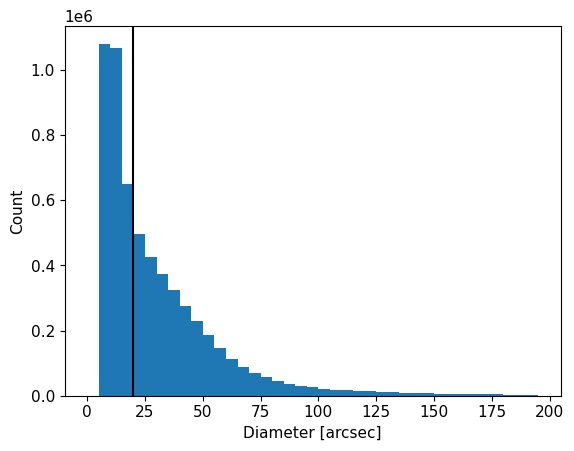

In [11]:
plt.hist(2*mock['R26_arcsec_true'], bins=np.arange(0,200,5))
plt.axvline(x=20, c='k')
plt.xlabel('Diameter [arcsec]')
plt.ylabel('Count')

In [12]:
mock_small = mock[mock['R26_arcsec_true'] < 10]
mock = mock[mock['R26_arcsec_true'] > 10]

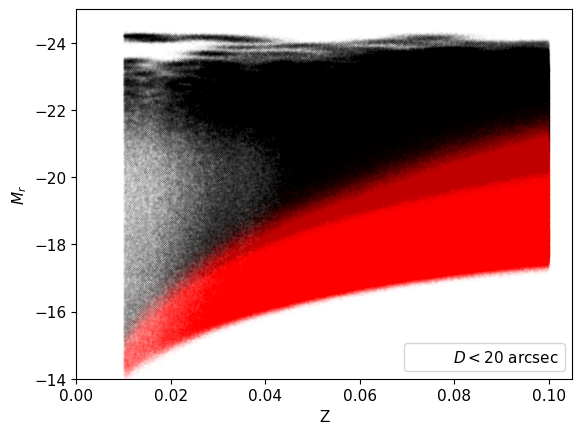

In [30]:
plt.figure()
plt.scatter(mock['zobs'], mock['R_ABSMAG_SB26_MOCK'], color='k', alpha=0.1, s=0.01)
plt.scatter(mock_small['zobs'], mock_small['R_ABSMAG_SB26_MOCK'], color='red', alpha=0.1, s=0.01, label=r'$D<20$ arcsec')
plt.xlim(0,0.105)
plt.ylim(-14,-25)
plt.xlabel('Z')
plt.ylabel(r'$M_r$')
plt.legend()
plt.show()

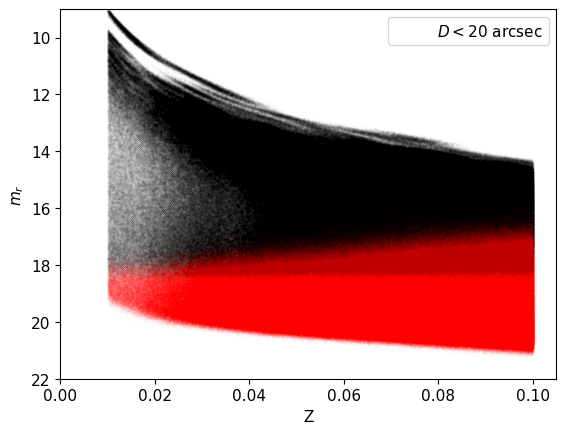

In [31]:
plt.figure()
plt.scatter(mock['zobs'], mock['app_mag_obs'], color='k', alpha=0.1, s=0.01)
plt.scatter(mock_small['zobs'], mock_small['app_mag_obs'], color='red', alpha=0.1, s=0.01, label=r'$D<20$ arcsec')
plt.xlim(0,0.105)
plt.ylim(22,9)
plt.xlabel('Z')
plt.ylabel(r'$m_r$')
plt.legend()
plt.show()

In [ ]:
plt.hist(mock['V_rot_obs'], bins=np.arange(0,500,10))
plt.axvline(x=10, c='k')
plt.xlabel('Vrot [km/s]')
plt.ylabel('Count')

In [14]:
mock = mock[mock['V_rot_obs'] > 10]

In [15]:
len(mock_small), len(mock), len(mock)/(len(mock)+len(mock_small))

(2799137, 3133353, 0.5281682733557073)

### Set up the Cosmology

Use a flat-$\Lambda$CDM fiducial cosmology with $H_0\equiv100$ km/s/Mpc and $\Omega_m=0.3151$.

In [16]:
h = 1
cosmology = FlatLambdaCDM(H0=100*h, Om0=0.3151)

#### Calculate distances to galaxies based on this cosmology
This will be useful in determining the selection effects

In [17]:
dist = Distance(z=np.abs(mock['zobs']), cosmology=cosmology)
mock['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*mock['D26'].values*u.arcmin)

### Current Y1 TFR Best Fit

TF Y1 best-fit parameters and covariances, corresponding to v9 of the TF Y1 catalog. This comes from the TFR calibration using 7 galaxy clusters (2025-03-28) using Vmax weights to account for the galaxy size function. The TFR fit is

$$
M_r = a \log_{10}{\left(\frac{V_\mathrm{rot}}{V_0}\right)} + b_{0\mathrm{pt}}
$$

with intrinsic scatter $\sigma$ along the magnitude axis. See this [notebook](https://github.com/DESI-UR/DESI_SGA/blob/master/TF/Y1/TF_Y1_cluster_calibration_AnthonyUpdates_weightsVmax-1_KAD.ipynb) in the [DESI_SGA/TF/Y1](https://github.com/DESI-UR/DESI_SGA/tree/master/TF/Y1) GitHub repo.

The parameter vector includes the TFR slope $a$, global zero point $b_{0\text{pt}}$, calibration cluster intercepts $\{b_i\}$, and intrinsic scatter $\sigma$.

### Current TFR Catalog

Read in the TFR catalog to sample uncertainties in $V_\mathrm{rot}$.

In [18]:
tfr_version = 'v10'

# tfrcatfile = os.path.join(pvpath, f'tfgalaxies/Y1/DESI-DR1_TF_pv_cat_{tfr_version}.fits')
# tfrcatfile = os.path.join(pvpath, f'tfgalaxies/Y1/systematic_tests/DESI-DR1_TF_pv_test_cat_{tfr_version}.fits')
tfrcatfile='/pscratch/sd/s/sgmoore1/TF/cats/SGA_iron_2dGaussian_030426.fits'
tfrcat = Table.read(tfrcatfile)
tfr_params = fits.open(tfrcatfile)
#- Set minimum velocity uncertainty to 7 km/s.
# lowverr = tfrcat['V_0p4R26_ERR'] < 7.
# tfrcat['V_0p4R26_ERR'][lowverr] = 7.

tfrcat['logv_rot'] = np.log10(tfrcat['V_0p4R26'])
tfrcat['logv_rot_err'] = 0.434*tfrcat['V_0p4R26_ERR'] / tfrcat['V_0p4R26']

tfrcat = tfrcat['Z_DESI', 'D26', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'R_ABSMAG_SB26', 'LOGDIST', 'LOGDIST_ERR', 'MU_ZCMB', 'MU_ZCMB_ERR', 'V_0p4R26', 'V_0p4R26_ERR', 'logv_rot', 'logv_rot_err', 'MAIN'].to_pandas()
tfrcat['R_ABSMAG_SB26_ERR'] = tfrcat['R_MAG_SB26_ERR_CORR']
tfrcat

,Z_DESI,D26,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,R_ABSMAG_SB26,LOGDIST,LOGDIST_ERR,MU_ZCMB,MU_ZCMB_ERR,V_0p4R26,V_0p4R26_ERR,logv_rot,logv_rot_err,MAIN,R_ABSMAG_SB26_ERR
0,0.080990,0.417579,16.715231,0.109794,-20.355425,0.105432,0.124338,37.070655,0.000752,122.322388,10.869519,2.087506,0.038565,True,0.109794
1,0.044002,0.495681,16.876765,0.087894,-18.849686,0.059728,0.069318,35.726451,0.001289,81.348133,6.577976,1.910348,0.035094,True,0.087894
2,0.090040,0.567250,15.939736,0.113037,-21.385827,0.064874,0.120452,37.325563,0.000978,180.655725,13.281536,2.256852,0.031907,True,0.113037
3,0.034026,0.575771,16.643692,0.098862,-18.507536,0.078685,0.071507,35.151228,0.001619,70.102003,12.043673,1.845730,0.074562,True,0.098862
4,0.043319,0.953031,15.209917,0.143845,-20.465230,0.070619,0.123828,35.675148,0.001354,133.778523,10.944416,2.126386,0.035506,True,0.143845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,0.116921,0.369286,16.648229,0.078975,-21.256834,0.444994,0.136799,37.905063,0.000531,95.032991,12.384687,1.977874,0.056559,False,0.078975
10196,0.054449,0.376227,17.080274,0.045130,-19.081032,0.369959,0.137208,36.161306,0.001144,44.540700,19.033877,1.648757,0.185464,True,0.045130
10197,0.118856,0.362001,17.638431,0.071668,-20.307229,0.099486,0.156327,37.945660,0.001205,123.942591,22.458671,2.093221,0.078642,True,0.071668
10198,0.133822,0.454465,17.365721,0.139803,-20.857233,-0.007474,0.130805,38.222953,0.000729,172.888233,18.437635,2.237765,0.046284,True,0.139803


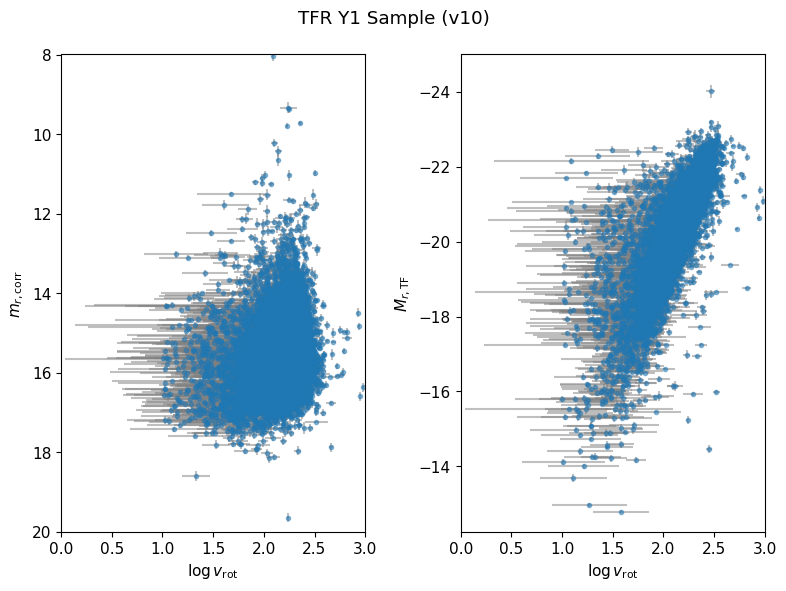

In [19]:
fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True)

ax = axes[0]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_MAG_SB26_CORR'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_MAG_SB26_ERR_CORR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$m_{r,\mathrm{corr}}$',
       ylim=(20,8))

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{TF}}$',
       ylim=(-12.25, -25))

fig.suptitle(f'TFR Y1 Sample ({tfr_version})')
fig.set_facecolor('none');
# fig.savefig('tfr_y1_sample.png', dpi=180);

#### Define likelihood formulas

In [20]:
def downsample(mock, size=100):
    """Randomly downsample a mock catalog, without replacement, to some size.

    Parameters
    ----------
    mock: pandas.DataFrame
        Pandas table with a mock catalog.
    size: int
        Size of the final downsampled catalog.

    Returns
    -------
    newmock: pandas.DataFrame
        Downsampled Pandas table.
    """
    Nmock = len(mock)
    idx_downsample = np.random.choice(Nmock, size, replace=False)
    return mock.iloc[idx_downsample]

def TF_logFN_func(params,
                  err_v,
                  err_M,
                  Mlim,
                  vmin=1.0,
                  vmax=3.0):

    vmean, Mmean, sigmav, sigmam, rho = params

    N = len(err_v)
    logFN = np.zeros(N)

    for i in range(N):

        sigV2 = sigmav**2 + err_v[i]**2
        sigM2 = sigmam**2 + err_M[i]**2

        sigV = np.sqrt(sigV2)
        sigM = np.sqrt(sigM2)

        rho_n = (rho * sigmav * sigmam) / (sigV * sigM)

        a = (vmin - vmean) / sigV
        b = (vmax - vmean) / sigV
        c = (Mlim[i] - Mmean) / sigM

        cov = [[1.0, rho_n],
               [rho_n, 1.0]]

        mvn = multivariate_normal(mean=[0,0], cov=cov)

        F = mvn.cdf([b, c]) - mvn.cdf([a, c])

        logFN[i] = np.log(max(F, 1e-300))

    return logFN

def TF_FP_func(params,
               logdists,
               v_obs, M_obs,
               err_v, err_M,
               Sn,
               Mlim,
               vmin=1.0,
               vmax=3.0,
               sumgals=True,
               chi_squared_only=False):

    vmean, Mmean, sigmav, sigmam, rho = params

    # Ensure arrays
    logdists = np.atleast_1d(logdists)
    N = v_obs.size
    nd = logdists.size

    # Broadcast for grid
    M = M_obs[None, :] + 5*logdists[:, None]   # (nd, N)
    v = v_obs[None, :]
    Sn = Sn[None, :]

    dv = v - vmean
    dM = M - Mmean

    cov_vm = rho * sigmav * sigmam

    C11 = sigmav**2 + err_v**2
    C22 = sigmam**2 + err_M**2
    C12 = cov_vm

    det = C11*C22 - C12**2

    inv11 = C22 / det
    inv22 = C11 / det
    inv12 = -C12 / det

    inv11 = inv11[None, :]
    inv22 = inv22[None, :]
    inv12 = inv12[None, :]
    det = det[None, :]

    chi2 = (inv11*dv**2 +
            inv22*dM**2 +
            2.0*inv12*dv*dM)

    if chi_squared_only:
        return chi2 / Sn

    log_det = np.log(det)


    logFN = TF_logFN_func(params,
                          err_v,
                          err_M,
                          Mlim,
                          vmin=vmin,
                          vmax=vmax)

    logFN = logFN[None, :]   # shape (1, N)
    # logFN=np.zeros(N)

    loglike = 0.5 * (
        chi2 / Sn
        + log_det / Sn
    ) - logFN / Sn

    if sumgals:
        return np.sum(loglike)
    else:
        return loglike, logFN


def ellipse_outliers(X, Y, params, sigma=3):

    vmean, Mmean, sigv, sigM, rho = params

    # Intrinsic covariance
    cov_vm = rho * sigv * sigM
    C = np.array([[sigv**2, cov_vm],
                  [cov_vm,   sigM**2]])

    Cinv = np.linalg.inv(C)

    dv = X - vmean
    dM = Y - Mmean

    chi2 = (Cinv[0,0]*dv**2 +
            Cinv[1,1]*dM**2 +
            2*Cinv[0,1]*dv*dM)

    threshold = stats.chi2.ppf(stats.norm.cdf(sigma) - stats.norm.cdf(-sigma), df=2)

    outliers = chi2 > threshold

    return outliers

def plot_TF_2D_contours(ax, params, 
                        xlim=(1,2.7), 
                        ylim=(-16.5,-23.5),
                        ngrid=300, colors='k'):

    vmean, Mmean, sigv, sigM, rho = params

    # Intrinsic covariance matrix
    cov_vm = rho * sigv * sigM
    C = np.array([[sigv**2, cov_vm],
                  [cov_vm,   sigM**2]])

    Cinv = np.linalg.inv(C)

    # Grid
    xv = np.linspace(*xlim, ngrid)
    yv = np.linspace(*ylim, ngrid)
    X, Y = np.meshgrid(xv, yv)

    dv = X - vmean
    dM = Y - Mmean

    # Compute chi^2 surface
    chi2 = (Cinv[0,0]*dv**2 +
            Cinv[1,1]*dM**2 +
            2*Cinv[0,1]*dv*dM)

    # 2D Gaussian confidence levels

    sig1 = stats.chi2.ppf(stats.norm.cdf(1) - stats.norm.cdf(-1), df=2)
    sig2 = stats.chi2.ppf(stats.norm.cdf(2) - stats.norm.cdf(-2), df=2)
    sig3 = stats.chi2.ppf(stats.norm.cdf(3) - stats.norm.cdf(-3), df=2)
    levels = [sig1,sig2,sig3]

    cs = ax.contour(X, Y, chi2,
                    levels=levels,
                    colors=colors,
                    linewidths=1.5,
                   )
    # Attach legend labels
    # labels = [r'1 $\sigma$',r'2 $\sigma$', r'3 $\sigma$']
    # for i, line in enumerate(cs.collections):
    #     line.set_label(labels[i])

    # ax.legend(frameon=False)

    return cs

#### Plot $M_{R,\mathrm{SB26}}$ for Mocks and TFR Data

Make a side-by-side comparison of the (downsampled) mock catalog and Y1 data.

Apply the quality cuts equally to both.

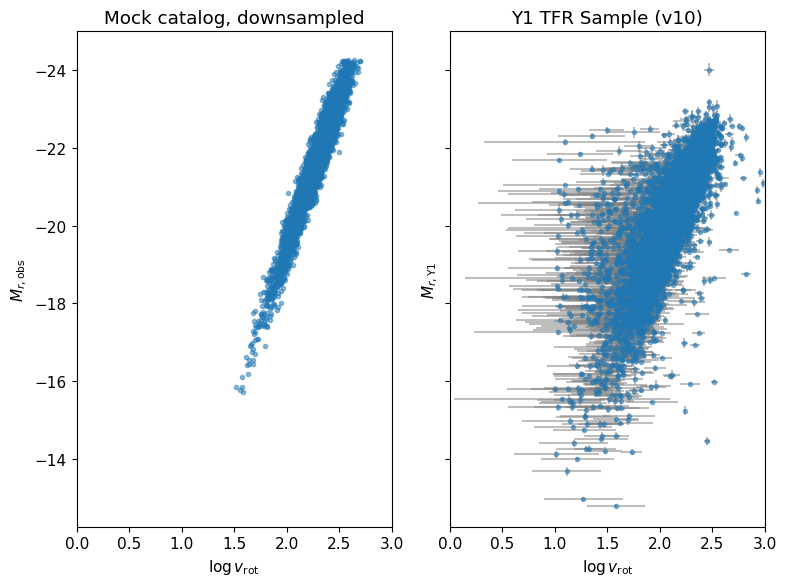

In [21]:
#- Plot Mr vs log(v_rot) for the various steps in the calculation.

fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True, sharey=True)

Ntfr = len(tfrcat)
mock_downsample = downsample(mock, 5000)

ax = axes[0]
ax.errorbar(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'],
            # xerr=mock_downsample['LOGVROT_ERR_MOCK'],
            # yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'],
            fmt='.', 
            alpha=0.5, 
            ecolor='gray')

# idx_mock_goodv = alex_cuts_velocity(mock_downsample, logv_name='LOGVROT_MOCK', distmod_name='MU_OBS_MOCK')
# idx_mock_notdwarf = alex_cuts_dwarf(mock_downsample, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_OBS_MOCK')
# idx_mock_good = idx_mock_goodv & idx_mock_notdwarf

# idx_tfr_good, idx_mock_good = ellipse_fit(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'], mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'])
# idx_mock_good = ellipse_boolean(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'], ellipse_mean, ellipse_cov, n_std=ellipse_sigma)

# ax.errorbar(mock_downsample['LOGVROT_MOCK'][idx_mock_good], mock_downsample['R_ABSMAG_SB26_MOCK'][idx_mock_good],
#              xerr=mock_downsample['LOGVROT_ERR_MOCK'][idx_mock_good],
#              yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'][idx_mock_good],
#              fmt='.', 
#              alpha=0.5, 
#              ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{obs}}$',
       ylim=(-12.25, -25),
       title=r'Mock catalog, downsampled')

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

# idx_tfr_goodv = alex_cuts_velocity(tfrcat, logv_name='logv_rot', distmod_name='MU_ZCMB')
# idx_tfr_notdwarf = alex_cuts_dwarf(tfrcat, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_ZCMB')
# idx_tfr_good = idx_tfr_goodv & idx_tfr_notdwarf
# idx_tfr_good = ellipse_boolean(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'], ellipse_mean, ellipse_cov, n_std=ellipse_sigma)

# ax.errorbar(tfrcat['logv_rot'][idx_tfr_good], tfrcat['R_ABSMAG_SB26'][idx_tfr_good],
#              xerr=tfrcat['logv_rot_err'][idx_tfr_good],
#              yerr=tfrcat['R_ABSMAG_SB26_ERR'][idx_tfr_good],
#              fmt='.', 
#              alpha=0.5, 
#              ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'Y1 TFR Sample ({tfr_version})');

fig.set_facecolor('none');
# fig.savefig('tfr_mock_mr_vs_logv.png', dpi=150);

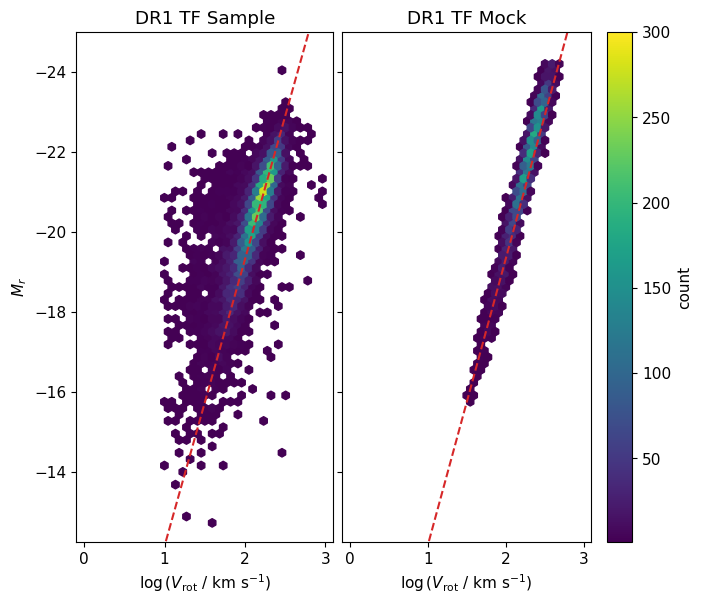

In [22]:
fig, axes = plt.subplots(1,2, figsize=(7,6), sharex=True, sharey=True,
                         gridspec_kw={'wspace':0.03, 'width_ratios':[0.825,1]})

ax = axes[0]
ax.hexbin(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'],
          cmap='viridis', mincnt=1, 
          vmin=1, vmax=3e2,
          gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       ylabel=r'$M_{r}$',
       ylim=(-12.25, -25),
       title=f'DR1 TF Sample')# ({tfr_version})');

_log_v_rot = np.arange(-0.1, 3.05, 0.05)
b0 = -5
a0 = -7.16
ax.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='tab:red')

ax = axes[1]
h = ax.hexbin(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'],
              cmap='viridis', mincnt=1, 
              vmin=1, vmax=3e2,
              gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
cb = fig.colorbar(h, ax=ax, label='count')

ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       # ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'DR1 TF Mock')

_log_v_rot = np.arange(-0.1, 3.05, 0.05)
b0 = -5
a0 = -7.16
ax.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='tab:red')

fig.subplots_adjust(left=0.1, right=0.925, top=0.95, bottom=0.1)
# fig.savefig('TF_mock_dr1_relation.png', dpi=200)

mpl.rc('font', size=11);

### Compute the luminosity distance and maximum volume for each galaxy

Since the SGA is size-limited, with $D_{26}>0.2'$, there is a maximum volume within which the galaxy could be located to be included in the SGA. Calculate the maximum volume to be used as a weight in the TFR calibration.

In [23]:
# Get some redshift-distance lookup tables
red_spline, lumred_spline, dist_spline, lumdist_spline, ez_spline, angred_spline, angdist_spline = rz_table()  ##redshift distance lookup tables. Can use astropy instead

In [24]:
# ##compute comoving distances for galaxies in our sample
# dz_sample_full = sp.interpolate.splev(mock["zobs"], dist_spline)
# dz_sample = sp.interpolate.splev(mock_downsample["zobs"].to_numpy(), dist_spline)

# ##define min and max redshift cuts
# zmin, zmax = 0, 0.1

# ##cubic volume limits given luminosity distance 
# Vmin, Vmax = (1.0+zmin)**3*sp.interpolate.splev(zmin, dist_spline)**3, (1.0+zmax)**3*sp.interpolate.splev(zmax, dist_spline)**3  

# ## logv limits (rotational velocities are between 10 and 1000 km/s
# logvmin, logvmax = 1,3

##compute comoving distances for galaxies in our sample
dz_sample_full = sp.interpolate.splev(mock["zobs"], dist_spline)
dz_sample = sp.interpolate.splev(mock_downsample["zobs"].to_numpy(), dist_spline)

##define min and max redshift cuts
zmin, zmax = 0, zmax

##cubic volume limits given luminosity distance 
# Vmin, Vmax = (1.0+zmin)**3*sp.interpolate.splev(zmin, dist_spline)**3, (1.0+zmax)**3*sp.interpolate.splev(zmax, dist_spline)**3  
Vmin, Vmax = 0, sp.interpolate.splev(zmax, angdist_spline)**3  

## logv limits (rotational velocities are between 10 and 1000 km/s
# logvmin, logvmax = 1,3

theta_min_arcsec = 20
theta_min=np.radians(theta_min_arcsec*u.arcsec).value

In [25]:
# ##compute max luminosity distance at which each individual galaxy would be observable based on the diameter limited sample
# theta_min=np.radians(20*u.arcsec).value
# Dlim = ((mock_downsample["D26_kpc"]/1e3)/ np.tan(theta_min))*(1.0 + mock_downsample["zobs"].to_numpy())**2 ### since distance should be in Mpc
# zlim = sp.interpolate.splev(Dlim, lumred_spline)  ##compute max redshift that each galaxy would be observable (based of luminosity)

z_obs = mock['zobs']
theta_obs = np.radians(mock["D26"]/60.0)

mock['DA_obs'] = sp.interpolate.splev(z_obs, angdist_spline)  # Mpc

#### Calculate the limiting redshift
zlim = np.zeros_like(z_obs)
for i in range(0,len(z_obs)):
    ### compute the coefficient based on the observed parameters
    K = (mock['DA_obs'].iloc[i]*theta_obs.iloc[i]/theta_min*(1+4*np.log(1+z_obs.iloc[i])))   
    
    def f(x):
        return (1+4*np.log(1+x))*sp.interpolate.splev(x, angdist_spline) - K

    # Choose an initial value of 0.1 so we choose the right zero of the function
    initial_guesses = [0.1]
    zlim[i] = [fsolve(f, x0)[0] for x0 in initial_guesses][0]
    ## See if there are any issues
    if zlim[i] < z_obs.iloc[i]:
        # print(f'Issue with row {i}: zobs={z_obs.iloc[i]}, zlim={zlim[i]}')
        zlim[i] = z_obs.iloc[i] ## because the galaxy is actually in the sample, let its observed redshift be the minimum

In [26]:
# ##### remove any object where the observed reshift is inconsistent with this limit:
# print(np.sum(zlim < mock_downsample["zobs"]))
# # mock_downsample = mock_downsample[zlim > mock_downsample["zobs"]]

# # ##### recompute for the galaxies that stay so we have the right sample size
# # Dlim = ((mock_downsample["D26_kpc"]/1e3)/ np.tan(theta_min))*(1.0 + mock_downsample["zobs"].to_numpy())**2 ### since distance should be in Mpc
# # zlim = sp.interpolate.splev(Dlim, lumred_spline)  ##compute max redshift that each galaxy would be observable (based of luminosity)

### Define the selection function weights

In [27]:
mock['zlim'] = zlim
mock['Dlim'] = sp.interpolate.splev(mock['zlim'], angdist_spline)

In [28]:
##compute selection effect weighting to account for incompleteness in sample caused by redshift and magnitude cuts 
## (based off fraction of survey volume where galaxy with magnitude m_r could be observed) 

mock['Sn'] = np.where(mock["zlim"] >= zmax, 1.0, np.where(mock["zlim"] <= zmin, 1e-5, (mock["Dlim"]**3 - Vmin)/(Vmax - Vmin))) 

### if we need to rescale the minimum value
mock['Sn'] = Snmin + (1-Snmin)*mock['Sn']

# Sn = np.ones(len(zlim)) ## if running with no weighting
# Sn = np.ones(len(mock_downsample))

mock['Mlim'] = (mock['R_ABSMAG_SB26_MOCK']+ 5.0*np.log10(mock['Dlim']/mock['DA_obs']))
# mock['MLIM'] = -13

(array([ 101128.,   85777.,   82098.,   83896.,   88147.,   93444.,
          97610.,  102903.,  105735., 2292615.]),
 array([0.00138267, 0.1012444 , 0.20110614, 0.30096787, 0.4008296 ,
        0.50069134, 0.60055307, 0.7004148 , 0.80027653, 0.90013827,
        1.        ]),
 <BarContainer object of 10 artists>)

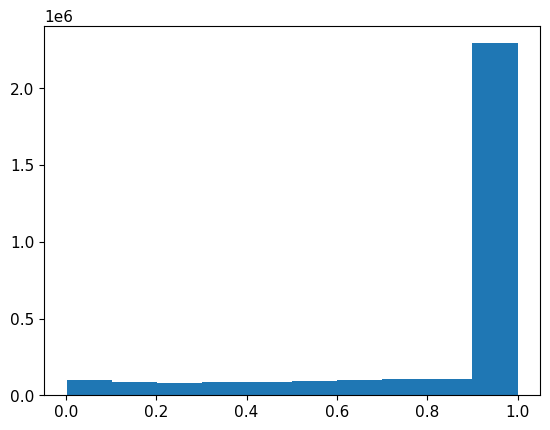

In [29]:
plt.hist(mock['Sn'])

## Fit 2D Gaussian to downsampled mock

In [106]:
mock_downsample = downsample(mock, 5000)
mock_downsample[:5]

,ra,dec,halo_ind,halo_mass,is_cen,is_res,vx,vy,vz,zcos,...,R_ABSMAG_SB26_ERR_MOCK,Sn,D26_kpc,DA_obs,zlim,Dlim,MLIM,MAIN,OUTLIER,Mlim
4020276,55.990411,32.604120,259478,3.619184e+12,False,True,228.671009,-404.832791,137.926333,0.030307,...,0.03,1.0,37.914509,86.592191,0.110487,290.416245,-13,True,False,-19.138452
1235589,171.910359,-51.688725,262524,4.867549e+13,False,True,81.080252,-364.800008,520.541515,0.070163,...,0.03,1.0,41.989707,188.853226,0.126010,325.389479,-13,False,True,-21.626268
5392744,23.102410,-49.985141,61704,7.294680e+13,False,True,-443.820925,-334.292508,563.945494,0.083485,...,0.03,1.0,57.097790,219.505739,0.165847,409.485337,-13,False,True,-21.609225
953071,145.032806,-56.762940,330263,2.914751e+12,True,True,86.560318,206.608170,47.410629,0.091575,...,0.03,1.0,33.370930,245.907045,0.105344,278.543811,-13,False,True,-21.479437
1195850,200.213931,33.424540,174747,1.948370e+13,False,True,-44.852079,-81.539445,415.681007,0.058625,...,0.03,1.0,50.271154,166.352378,0.145850,368.259405,-13,False,True,-20.811412


In [107]:
##### Initialize the fitting sample and outlier list for the iterative fit
data_fit = mock_downsample
badcount = len(mock_downsample)
print(len(data_fit), badcount)

# Fit the TFR
ii = 0
converged = False  ##initialise convergence flag for fitting algorithm
start = time.time()
while not converged: ##FP fitting algorithm (see Howlett et. al., 2022 for details)

    ii += 1
    dz_sample_fit = sp.interpolate.splev(data_fit["zobs"].to_numpy(), dist_spline) ##compute cluster comoving distance for fitting subset(subset of dz_cluster_nosirals)
    Dlim = ((data_fit["D26_kpc"]/1e3)/ np.tan(theta_min))*(1.0 + data_fit["zobs"].to_numpy())**2  ##max observable luminsity distance of galaxy for fitting subset(subset of prev. Dlim)
    zlim = sp.interpolate.splev(Dlim, lumred_spline)  ##max observable redshift of galaxy for fitting subset(subset of prev. zlim)
    # Snfit = np.where(zlim >= zmax, 1.0, np.where(zlim <= zmin, 1e-7, (Dlim**3 - Vmin)/(Vmax - Vmin))) ##compute selection effect weighting (Sn) for fitting subset(subset of prev. Sn)
    # Snfit = Snmin + (1-Snmin)*Snfit ### to rescale it between 0.001 and 1
    # Snfit = 0.001 + 0.999*Snfit ### to rescale it between 0.001 and 1
    # Snfit=np.ones(len(data_fit))
    # Snfit = np.ones(len(zlim)) ##affectively removes weighting parameter Sn
    Mlim_fit = (data_fit['R_ABSMAG_SB26_MOCK'].to_numpy()+ 5.0*np.log10(60*data_fit['D26'].to_numpy()/20))

    # ----- Parameter bounds -----
    vvals   = (1.0, 3.0)        # mean logV
    Mvals   = (-24.0, -10.0)    # mean magnitude
    svvals  = (0.01, 0.5)       # intrinsic scatter logV
    smvals  = (0.01, 3)       # intrinsic scatter M
    rhovals = (-1, 0.98)     # correlation coefficient
    bounds = (vvals, Mvals, svvals, smvals, rhovals)
    x0 = np.array([np.mean(data_fit['LOGVROT_MOCK']), np.mean(data_fit['R_ABSMAG_SB26_MOCK']), 0.2, 1.5, -0.7])

    TFparams = sp.optimize.minimize(TF_FP_func, x0, bounds=bounds,
                                args=(0.0,  # placeholder for logdists
                                      data_fit["LOGVROT_MOCK"].to_numpy(),        # observed log velocities
                                      data_fit["R_ABSMAG_SB26_MOCK"].to_numpy(),  # observed magnitudes
                                      data_fit["LOGVROT_ERR_MOCK"].to_numpy(),    # velocity errors
                                      data_fit["R_ABSMAG_SB26_ERR_MOCK"].to_numpy(),  # magnitude errors
                                      data_fit["Sn"].to_numpy(),
                                      Mlim_fit,
                                      logvmin, logvmax),
                                method="L-BFGS-B",
                                options={"maxiter": 500})


    #computes (x-xmean)C_n^{-1}(x-xmean)^T for all TF galaxies
    chi_squared = mock_downsample["Sn"].to_numpy()*TF_FP_func(TFparams.x, 0.0,
                            mock_downsample["LOGVROT_MOCK"].to_numpy(),
                            mock_downsample["R_ABSMAG_SB26_MOCK"].to_numpy(),
                            mock_downsample["LOGVROT_ERR_MOCK"].to_numpy(),
                            mock_downsample["R_ABSMAG_SB26_ERR_MOCK"].to_numpy(),
                            mock_downsample["Sn"].to_numpy(),
                            mock_downsample["MLIM"].to_numpy(),
                            logvmin, logvmax,
                            sumgals=False,
                            chi_squared_only=True)[0]


    ##compute p-value of fit for all calibration galaxies (five parameters: m , logv, sig_m, sig_v, rho/cov)
    dof = 5
    pvals = stats.chi2.sf(chi_squared, np.sum(chi_squared)/(len(mock_downsample) - dof)) 

    ##reassign data_fit with galaxies that have pvalue>0.01 (not outliers)
    data_fit = mock_downsample.drop(mock_downsample[pvals < 0.01].index).reset_index(drop=True)
    badcountnew = len(np.where(pvals < 0.01)[0]) ##count of all removed outliers
    converged = True if badcount == badcountnew else False  ##update converged to end loop if the number of outliers hasn't changed
    print(TFparams.x, np.sum(chi_squared), len(data_fit), stats.chi2.isf(0.01, np.sum(chi_squared)/(len(mock_downsample) - dof)), np.sum(chi_squared)/(len(mock_downsample) - dof), badcount, badcountnew, converged)
    print(f'Reduced chi^2 value = {np.sum(chi_squared) / (len(mock_downsample) - dof):.4f}')
    badcount = badcountnew

print(time.time()-start)


5000 5000
[  2.08690017 -20.11029161   0.32132745   2.58145633  -0.99475424] 7989.289040581409 4977 8.258413128137699 1.5994572653816634 5000 23 False
Reduced chi^2 value = 1.5995
[  2.08642249 -20.10498011   0.32123738   2.58110782  -0.99497356] 8111.5388787679985 4976 8.318900861130206 1.6239317074610609 23 24 False
Reduced chi^2 value = 1.6239
[  2.08640873 -20.10474763   0.32124665   2.58109858  -0.99497907] 8114.631205036667 4976 8.320426455212761 1.6245507917991324 24 24 True
Reduced chi^2 value = 1.6246
746.8227097988129


In [91]:
np.mean(mock['LOGVROT_MOCK'])

2.2885952856870317

In [108]:
vmean, Mmean, sigmav, sigmam, rho = TFparams.x
logV0 = np.mean(mock['LOGVROT_MOCK'])
# logV0 = 2.18
a = rho * (sigmam / sigmav)
b = Mmean +  a * (logV0-vmean)
# b = Mmean +  a * (2.18-vmean)
sigma_int = sigmam * np.sqrt(1.0 - rho**2)
print(a,b,sigma_int)

-7.9942905358346845 -21.72108573288639 0.2583246946223639


In [94]:
pvals

array([0.14236325, 0.93918614, 0.53603629, ..., 0.35966265, 0.48338   ,
       0.82118584])

In [109]:
outlier_boolean = pvals < 0.01

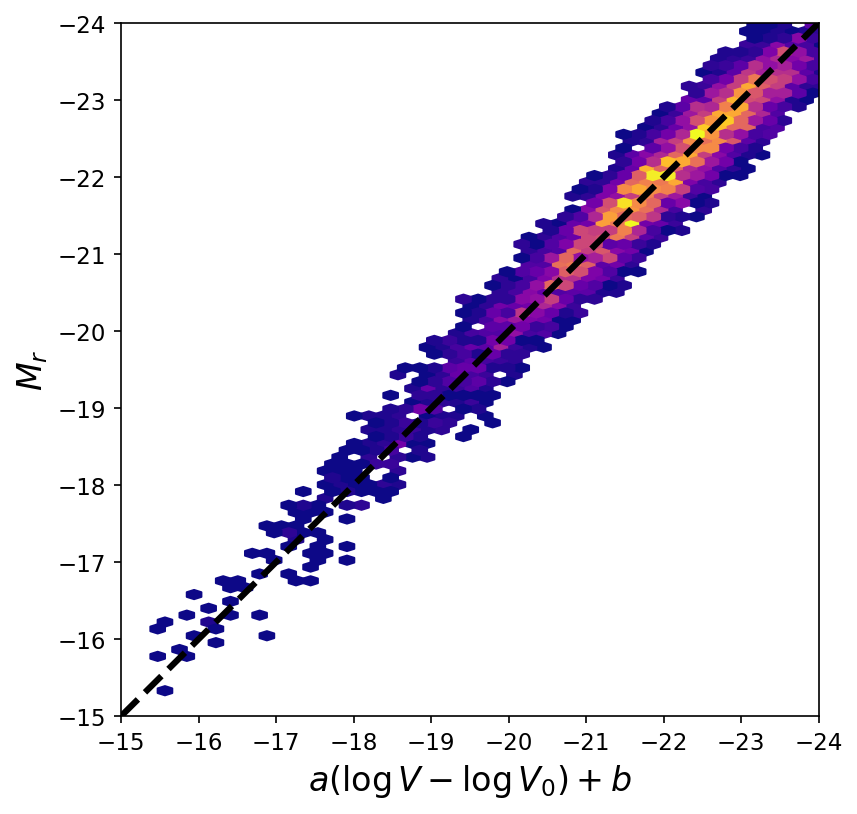

In [110]:
plt.figure(figsize=(6,6), facecolor='none', dpi=150)
plt.hexbin(x=a*(data_fit['LOGVROT_MOCK']-logV0) +b, y = data_fit['R_ABSMAG_SB26_MOCK'], cmap='plasma', mincnt=1, gridsize=(50,50), )
plt.xlabel(r'$a (\log V - \log V_0) + b$', fontsize=16)
plt.ylabel(r'$M_r$', fontsize=16)
plt.plot([-30,-10], [-30,-10], 'k--', lw=3, zorder=5)

plt.xlim(-15,-24)
plt.ylim(-15,-24)
plt.show()

/global/homes/s/sgmoore1/.local/lib/python3.10/site-packages/astroML/plotting/scatter_contour.py:96: UserWarning: linewidths is ignored by contourf
  contours = ax.contourf(H.T, levels, extent=extent, **contour_args)


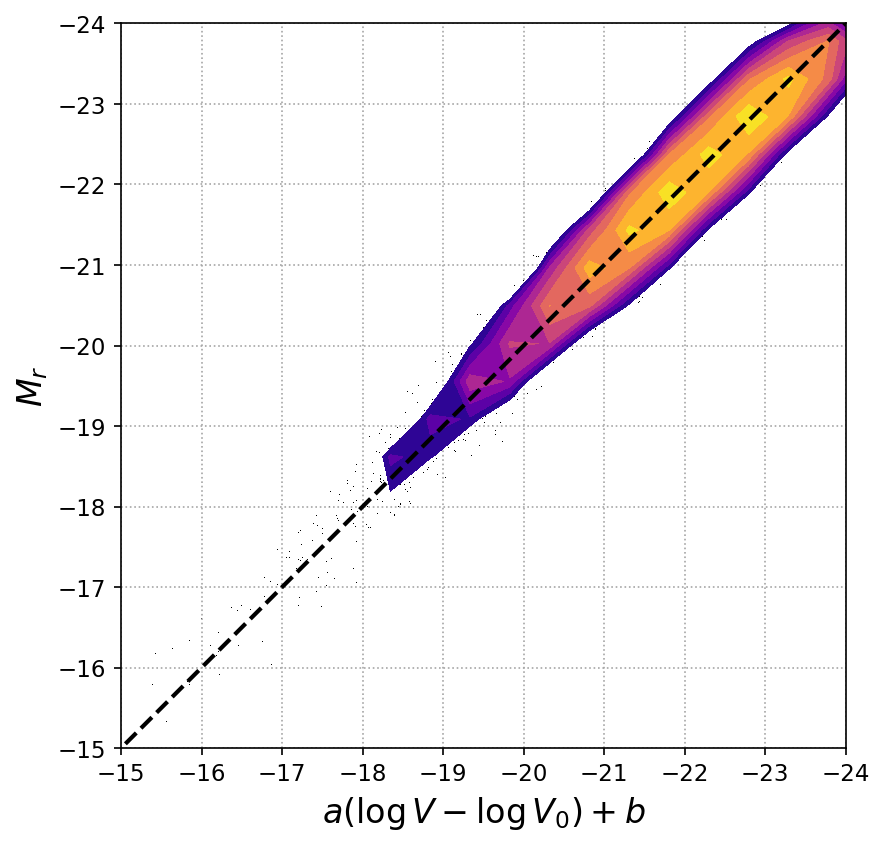

In [111]:
fig, ax = plt.subplots(figsize=(6,6), facecolor='none', dpi=150)
ax.set_xlim(-15, -24)
ax.set_ylim(-15, -24)

# Scatter + Gaussian-like density contours
scatter_contour(a*(data_fit['LOGVROT_MOCK']-logV0) + b, data_fit['R_ABSMAG_SB26_MOCK'],
                threshold=25, log_counts=True, ax=ax,
               histogram2d_args=dict(bins=20),
               plot_args=dict(marker=',', linestyle='none', color='black'),
               contour_args=dict(cmap=plt.cm.plasma, linewidths=2))

# y=x reference line
ax.plot([-25, -14], [-25, -14], 'k--', lw=2, label='y=x')

# Labels
ax.set_xlabel(r'$a (\log V - \log V_0) + b$', fontsize=16)
ax.set_ylabel(r'$M_r$', fontsize=16)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', color='0.65')
plt.tight_layout()
plt.show()


### Apply outlier identification to full sample
Use the sample probabilistic cut during the fitting

In [112]:
#### Now compute the chi^2 values to determine outliers in the full sample
theta_min_arcsec=20

# zmin, zmax = 0, 0.1
# Vmin, Vmax = (1.0+zmin)**3*sp.interpolate.splev(zmin, dist_spline)**3, (1.0+zmax)**3*sp.interpolate.splev(zmax, dist_spline)**3  

Dlim = ((mock["D26_kpc"]/1e3)/ np.tan(theta_min))*(1.0 + mock["zobs"].to_numpy())**2 ### since distance should be in Mpc
zlim = sp.interpolate.splev(Dlim, lumred_spline)  ##compute max redshift that each galaxy would be observable (based of luminosity)
Sn = np.where(zlim >= zmax, 1.0, np.where(zlim <= zmin, 0, (Dlim**3 - Vmin)/(Vmax - Vmin))) ##compute selection effect weighting to account for incompleteness in sample caused by redshift and magnitude cuts (based off fraction of survey volume where galaxy with magnitude m_r could be observed) 
# mock["Sn"] = Snmin + (1-Snmin)*Sn ### to rescale it between 0.001 and 1
mock["Sn"] = 0.001+ 0.999*Sn ### to rescale it between 0.001 and 1
# mock['Sn'] = np.ones(len(zlim))
# Mlim = (mock['R_ABSMAG_SB26_MOCK'].to_numpy()+ 5.0*np.log10(60*mock['D26'].to_numpy()/20))


chi_squared = mock['Sn']*TF_FP_func(TFparams.x, 0.0,
                        mock["LOGVROT_MOCK"].to_numpy(),
                        mock["R_ABSMAG_SB26_MOCK"].to_numpy(),
                        mock["LOGVROT_ERR_MOCK"].to_numpy(),
                        mock["R_ABSMAG_SB26_ERR_MOCK"].to_numpy(),
                        mock['Sn'].to_numpy(),
                        mock['MLIM'].to_numpy(),
                        logvmin, logvmax,
                        sumgals=False,
                        chi_squared_only=True)[0]

dof=5
pvals = stats.chi2.sf(chi_squared, np.sum(chi_squared)/(len(mock) - dof)) 

outlier_boolean = pvals < 0.01
print(np.sum(outlier_boolean))
print(len(np.where(pvals < 0.01)[0])/len(pvals))

15057
0.00480539537039076


In [113]:
outlier_3sig = ellipse_outliers(mock['LOGVROT_MOCK'], mock['R_ABSMAG_SB26_MOCK'], TFparams.x, 3)
outlier_2sig = ellipse_outliers(mock['LOGVROT_MOCK'], mock['R_ABSMAG_SB26_MOCK'], TFparams.x, 2)
outlier_1sig = ellipse_outliers(mock['LOGVROT_MOCK'], mock['R_ABSMAG_SB26_MOCK'], TFparams.x, 1)

# outlier_3sig = ellipse_outliers(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'], TFparams.x, 3)
# outlier_2sig = ellipse_outliers(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'], TFparams.x, 2)
# outlier_1sig = ellipse_outliers(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'], TFparams.x, 1)

In [100]:
pvals

array([0.57566311, 0.89815246, 0.53944826, ..., 0.1440284 , 0.27177068,
       0.18236321])

In [102]:
# plt.figure(figsize=(8,8))
# sc = plt.scatter(x=a*(mock_downsample['LOGVROT_MOCK'][~outlier_boolean]-logV0) +b, y = mock_downsample['R_ABSMAG_SB26_MOCK'][~outlier_boolean], c=pvals[~outlier_boolean], s=2, alpha=1)
# plt.scatter(x=a*(mock_downsample['LOGVROT_MOCK'][outlier_boolean]-logV0) +b, y = mock_downsample['R_ABSMAG_SB26_MOCK'][outlier_boolean], c='k', s=2, alpha=1)

# plt.xlabel(r'$a (\log V - \log V_0) + b$', fontsize=16)
# plt.ylabel(r'$M_r$', fontsize=16)
# plt.plot([-30,-10], [-30,-10], 'k--', lw=3, zorder=5)
# plt.colorbar(sc, label='pvals')

# plt.xlim(-15,-24)
# plt.ylim(-15,-24)
# plt.show()

In [45]:
np.sum(outlier_boolean)/len(outlier_boolean)

0.004

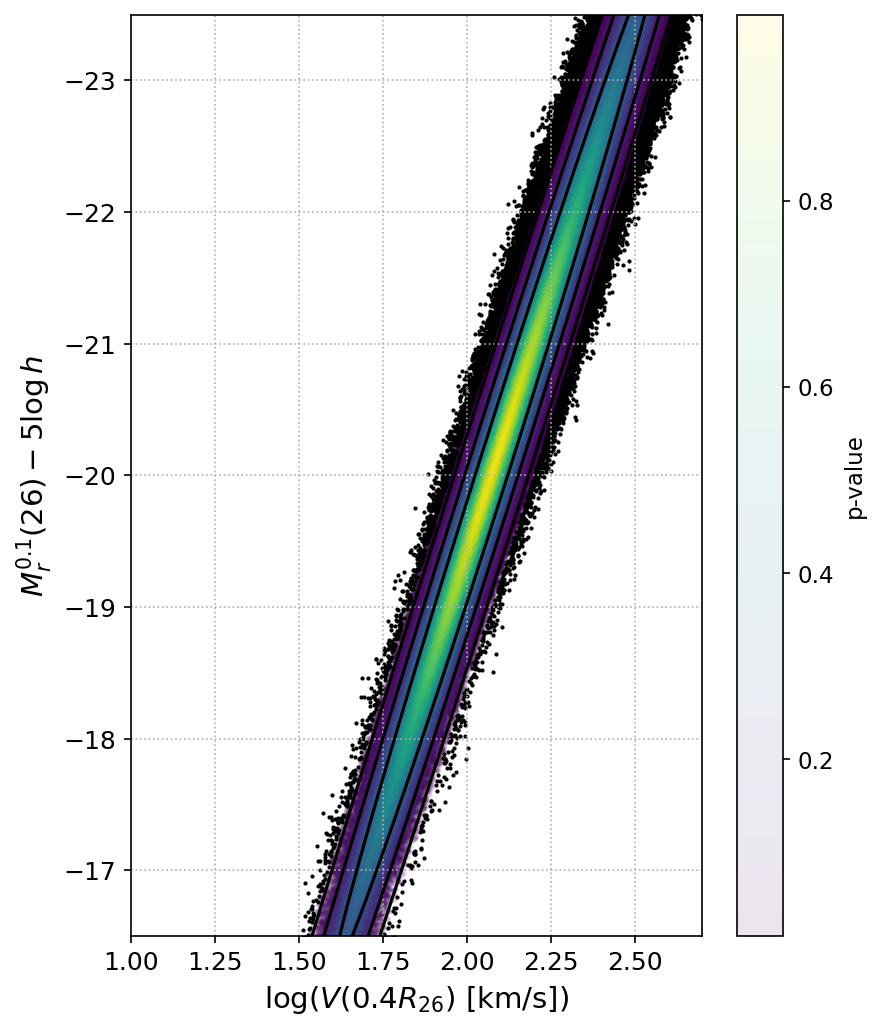

In [114]:
### Comparing methods of calculating logdist values:

plt.figure(figsize=(6,7), tight_layout=True, dpi=150, facecolor='none')

plt.grid(ls=':')
sample = ~outlier_boolean
# sample = ~outlier_boolean# & morph_boolean
sc = plt.scatter(mock['LOGVROT_MOCK'][sample], 
             mock['R_ABSMAG_SB26_MOCK'][sample],
            c=pvals[sample], s=3, alpha=0.1)

plt.scatter(mock['LOGVROT_MOCK'][~sample], 
             mock['R_ABSMAG_SB26_MOCK'][~sample], s=1, c='k')
plt.colorbar(sc, label=r'p-value')

# sample = ~outlier_boolean_alt & outlier_boolean
# plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
#              sgatab['R_ABSMAG_SB26'][sample], 
#              xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
#              yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
#              fmt='.', 
#              markersize=4, 
#              alpha=0.2, 
#              ecolor='gray')
ax = plt.gca()
plot_TF_2D_contours(ax, TFparams.x)


# plt.xlim([0.5, 3.1])

# plt.ylim([-12.25, -24.5])
# plt.plot([1,3], a*([1,3]-logV0) + b, 'k--')
plt.xlim([1, 2.7])
plt.ylim([-16.5, -23.5])
# plt.legend()
plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);
# plt.title(r'Fit $\eta$ values')
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);
# plt.legend()
# plt.savefig('../../Figures/Y1/iron_jointTFR_varyV0-perpdwarf_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [48]:
mock['MAIN'] = ~outlier_1sig
mock['OUTLIER'] = outlier_1sig
mock_main = mock['MAIN']

## Compute Eta values

The distance modulus is defined as 

$$
\mu_\mathrm{TF} =  m_{r,\mathrm{SB_{26}}} - M_{r,\mathrm{TF}}.
$$

and the logdistance ratios by 

$$
\eta = \log{\left(\frac{D_z}{D_\mathrm{TFR}}\right)}
$$

But in this case, we can fit for the $\eta$ values based on the following integral:

$$
[type integral]
$$

The bounds on our likelihood are given by
$$ v_{min} = \log(10), v_{max} = \log(1000)$$
based on our velocity cuts, and then based on the diameter-limited sample, we have the following magnitude limit:

$$ M_\mathrm{lim} = \mu_{\rm iso} - 5 \log_{10}(\theta_{\rm min}) - 5 \log_{10}(D_L / 10\ \mathrm{pc})$$

where $\mu = 26$ based on the isophote we use, $D_L$ = luminosity distance in pc

### Calculate the true $\eta$ value

In [55]:
mu_zcmb = cosmology.distmod(mock_downsample['zobs']).to_value('mag')
mu_zcos = cosmology.distmod(mock_downsample['zcos']).to_value('mag')

eta_true = 0.2 * (mu_zcmb - mu_zcos)

### Fit for measured $\eta$

In [50]:
# Fit the log-distance ratios
dmin, dmax, nd = -1.5, 1.5, 1001  # log-distance ratio limits
# dmin, dmax, nd = -1, 1, 1001  # log-distance ratio limits

dbins = np.linspace(dmin, dmax, nd, endpoint=True)  # bins for log-distance shifts
d_H = 10.0**(-dbins)[:, None] * dz_sample_full[None, :]  # multiply each galaxy by each dbin
# -------------------------------------------------------
# Fit the log-distance ratios
# -------------------------------------------------------

dmin, dmax, nd = -1.5, 1.5, 1001
dbins = np.linspace(dmin, dmax, nd)

# Velocity limits
logvmin = np.log10(10)
logvmax = np.log10(1000)

# theta_min = 20.0  # arcsec
# Mlim = (
#     mock['R_ABSMAG_SB26_MOCK'].to_numpy()
#     + 5.0*np.log10(60*mock['D26'].to_numpy()/theta_min_arcsec))

# -------------------------------------------------------
# Compute likelihood grid
# -------------------------------------------------------

loglike, FNvals = TF_FP_func(
    TFparams.x,                        # best-fit parameters
    dbins,                             # log-distance shifts (vector)
    mock_downsample["LOGVROT_MOCK"].to_numpy(),        # observed log velocities
    mock_downsample["R_ABSMAG_SB26_MOCK"].to_numpy(),  # observed magnitudes
    mock_downsample["LOGVROT_ERR_MOCK"].to_numpy(),
    mock_downsample["R_ABSMAG_SB26_ERR_MOCK"].to_numpy(),
    Sn=mock_downsample['Sn'].to_numpy(),
    Mlim=mock_downsample['MLIM'].to_numpy(),
    vmin=logvmin,
    vmax=logvmax,
    sumgals=False,                    
    chi_squared_only=False,
)

In [51]:
logP_dist = -loglike

dd = dbins[1] - dbins[0]
Ngal = logP_dist.shape[1]

# Normalize using log-sum-exp trapezoid rule
log_norm = np.zeros(Ngal)

for i in range(Ngal):
    lp1 = logP_dist[:-1, i]
    lp2 = logP_dist[1:, i]
    m = np.maximum(lp1, lp2)
    logsum = m + np.log(np.exp(lp1 - m) + np.exp(lp2 - m))
    log_terms = logsum + np.log(dd)

    m2 = np.max(log_terms)
    log_norm[i] = m2 + np.log(np.sum(np.exp(log_terms - m2))) - np.log(2.0)

logP_dist -= log_norm[None, :]

mean   = np.zeros(Ngal)
second = np.zeros(Ngal)
third  = np.zeros(Ngal)

for i in range(Ngal):
    lp = logP_dist[:, i]
    m = np.max(lp)
    weights = np.exp(lp - m)
    Z = np.sum(weights) * dd

    mean[i]   = np.sum(dbins * weights) * dd / Z
    second[i] = np.sum(dbins**2 * weights) * dd / Z
    third[i]  = np.sum(dbins**3 * weights) * dd / Z


# Variance (force small negatives to zero)
var = second - mean**2
var = np.maximum(var, 0.0)
err = np.sqrt(var)

# Skewness 
gamma1 = np.zeros_like(err)
mask = err > 0

gamma1[mask] = (third[mask] - 3.0*mean[mask]*var[mask] - mean[mask]**3) / err[mask]**3

gamma1 = np.clip(gamma1, -0.99, 0.99)

# Skew-normal parameters
delta = np.sign(gamma1) * np.sqrt((np.pi/2.0) /(1.0 + ((4.0 - np.pi)/(2.0*np.abs(gamma1)))**(2.0/3.0)))

scale = err * np.sqrt(1.0/(1.0 - 2.0*delta**2/np.pi))
loc   = mean - scale*delta*np.sqrt(2.0/np.pi)
alpha = delta / np.sqrt(1.0 - delta**2)

/tmp/ipykernel_2118226/1638122006.py:50: RuntimeWarning: divide by zero encountered in true_divide
  delta = np.sign(gamma1) * np.sqrt((np.pi/2.0) /(1.0 + ((4.0 - np.pi)/(2.0*np.abs(gamma1)))**(2.0/3.0)))


In [52]:
##save log-distance values
print(mean, err, alpha)
mock_downsample["LOGDIST"] = mean ##mean of weighted likelihood gaussian 
mock_downsample["LOGDIST_ERR"] = err ##varience of weighted likelihood gaussian
mock_downsample["LOGDIST_alpha"] = alpha ##skew of weighted likelihood gaussian
print(len(mock))
# TFparam_df['MEAN_LOGDIST'] = np.mean(sgatab["LOGDIST"])

[-0.07617185 -0.06980383  0.03432082 ...  0.03315032 -0.04850076
  0.03593162] [0.06544968 0.06544968 0.05067977 ... 0.06544968 0.06544968 0.06544968] [ 1.92156320e-05 -1.21050896e-05  1.53002319e-05 ...  1.30398125e-05
  3.05029145e-05 -6.05254481e-06]
3139639


/tmp/ipykernel_2118226/298660369.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mock_downsample["LOGDIST"] = mean ##mean of weighted likelihood gaussian
/tmp/ipykernel_2118226/298660369.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mock_downsample["LOGDIST_ERR"] = err ##varience of weighted likelihood gaussian
/tmp/ipykernel_2118226/298660369.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

In [53]:
### Save the logdistance values:
eta_mock = mean
eta_err_mock = err

### Calculate the corresponding $\mu$ values:

In [63]:
mu_TF = mu_zcmb - 5*eta_mock
mu_TF_err = 5*eta_err_mock
# mock_main = ~outlier_1sig

## Diagnostic Plots

### $\eta$ dependence with $z$

In [65]:
idx_mock_good = ~outlier_boolean
mock_main = ~outlier_boolean
# idx_mock_good = ~outlier_1sig

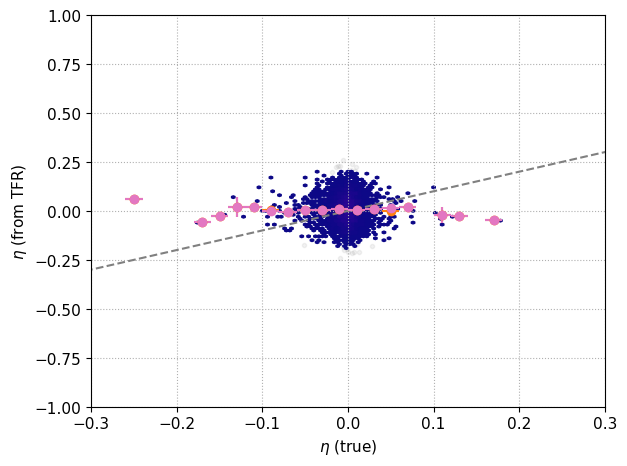

In [60]:
plt.figure(tight_layout=True)

plt.plot(eta_true[~idx_mock_good], eta_mock[~idx_mock_good], '.', c='gray', alpha=0.1, zorder=0)
# plt.plot(eta_true[mock_main], eta_mock[mock_main], '.', alpha=0.1, zorder=1)
plt.hexbin(eta_true[idx_mock_good], 
           eta_mock[idx_mock_good], 
           cmap='plasma', 
           mincnt=1, 
           vmin=1, 
           vmax=1000, 
           gridsize=(100,100), 
           extent=(-0.2, 0.2, -1, 1))

plt.plot([-5, 2], [-5, 2], '--', c='gray')

eta_bins = np.arange(-0.5, 0.3, 0.02)
d_eta = 0.5*np.diff(eta_bins)
eta_c = 0.5*(eta_bins[1:] + eta_bins[:-1])

_, eta_avg, eta_std = profile_histogram(eta_true[idx_mock_good], eta_mock[idx_mock_good], eta_bins, stat='median')
plt.errorbar(eta_c, eta_avg, xerr=d_eta, yerr=eta_std, fmt='o', color='tab:orange', zorder=2)

_, eta_avg, eta_std = profile_histogram(eta_true[~outlier_3sig], eta_mock[~outlier_3sig], eta_bins, stat='median')
plt.errorbar(eta_c, eta_avg, xerr=d_eta, yerr=eta_std, fmt='o', color='tab:pink', zorder=2)

plt.grid(ls=':')

# plt.xlim([-0.2, 0.2])
plt.xlim([-0.3,0.3])
plt.ylim([-1, 1])

plt.xlabel(r'$\eta$ (true)')
plt.ylabel(r'$\eta$ (from TFR)');

In [81]:
# zbins = np.arange(0, 0.105, 0.005)
# fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True)

# ax.scatter(mock['zobs'][idx_mock_good], eta_true[idx_mock_good] - eta_mock[idx_mock_good], alpha=0.2, marker='.')

# _, deta_avg, deta_std = profile_histogram(mock['zobs'][idx_mock_good], eta_true[idx_mock_good] - eta_mock[idx_mock_good], zbins)
# ax.errorbar(zc, deta_avg, xerr=dz, yerr=deta_std, fmt='o', color='tab:orange')

# ax.set(xlabel=r'$z_\mathrm{obs}$',
#        xlim=(-0.005,0.1),
#        ylim=(-1,1),
#        ylabel=r'$\eta_\mathrm{true} - \eta_\mathrm{TF}$');

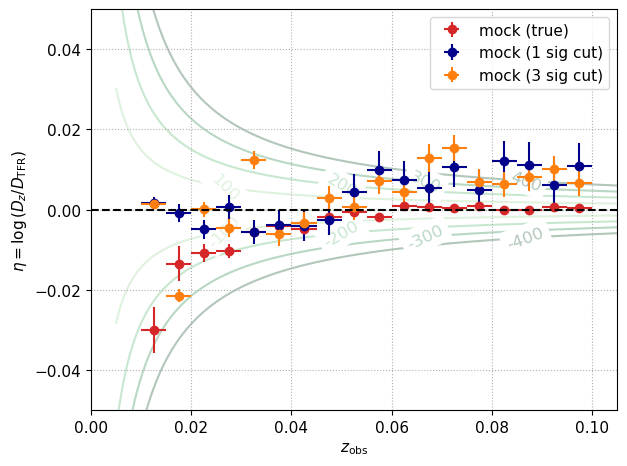

In [68]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock['zobs'][mock_main], 
                                        eta_true[mock_main], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# Mock
_, eta_avg, eta_std = profile_histogram(mock['zobs'][~outlier_1sig], 
                                        eta_mock[~outlier_1sig], 
                                        _zbins, 
                                        weights=eta_err_mock[~outlier_1sig]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='mock (1 sig cut)')

_, eta_avg, eta_std = profile_histogram(mock['zobs'][~outlier_3sig], 
                                        eta_mock[~outlier_3sig], 
                                        _zbins, 
                                        weights=eta_err_mock[~outlier_3sig]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange', label='mock (3 sig cut)')

# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')

plt.xlim(0,0.105)
plt.ylim(-0.05, 0.05);
# plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

In [83]:
eta_avg

array([-0.20058413, -0.0319211 ,  0.0254609 ,  0.03914718,  0.03995163,
        0.04157557,  0.03759673,  0.03106401,  0.02591775,  0.01592612,
        0.00706166, -0.00079965, -0.00859306, -0.01520995, -0.02020311,
       -0.02450422, -0.02952306, -0.0319152 , -0.03296781, -0.03784519])

(0.0, 0.105)

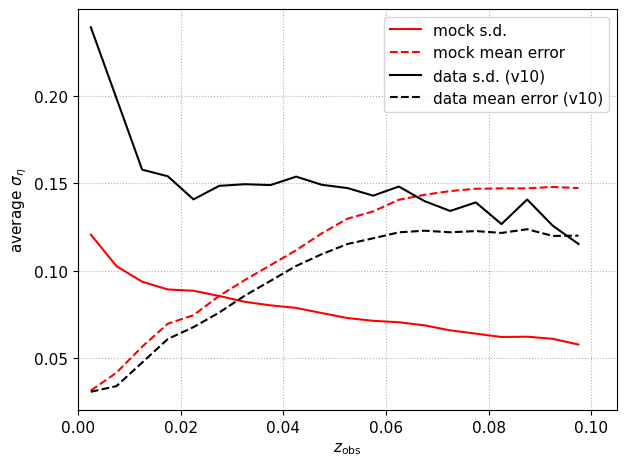

In [84]:
# In each redshift bin, compute the standard deviation of the log-distance ratios
# And compare this to the average value of the uncertainty in the log-distance ratio in each bin
# Do this for both mocks and data

plt.figure(tight_layout=True)

plt.grid(ls=':')

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])

# Mock standard deviation in each bin
_, eta_std,_ = profile_histogram(mock['zobs'][mock_main], 
                                 eta_mock[mock_main], 
                                 _zbins, 
                                 stat='std')
plt.plot(zc, eta_std, 'r', label='mock s.d.')

# Mock average error
_, eta_err_avg,_ = profile_histogram(mock['zobs'][mock_main], 
                                     eta_err_mock[mock_main], 
                                     _zbins)
plt.plot(zc, eta_err_avg, 'r--', label='mock mean error')

# Data standard deviation in each bin
_, data_eta_std,_ = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
                                      tfrcat['LOGDIST'][tfrcat['MAIN']], 
                                      _zbins, 
                                      stat='std')
plt.plot(zc, data_eta_std, 'k', label=f'data s.d. ({tfr_version})')

# Data average error
_, data_eta_err_avg,_ = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
                                          tfrcat['LOGDIST_ERR'][tfrcat['MAIN']], 
                                          _zbins)
plt.plot(zc, data_eta_err_avg, 'k--', label=f'data mean error ({tfr_version})')


plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'average $\sigma_\eta$')

plt.xlim(0,0.105)
# plt.ylim(0.08, 0.18);

/tmp/ipykernel_102343/497888321.py:1: RuntimeWarning: invalid value encountered in log10
  logdist_true = np.log10(cosmology.comoving_distance(mock['zobs'].to_numpy()).value/cosmology.comoving_distance(mock['zcos'].to_numpy()).value)


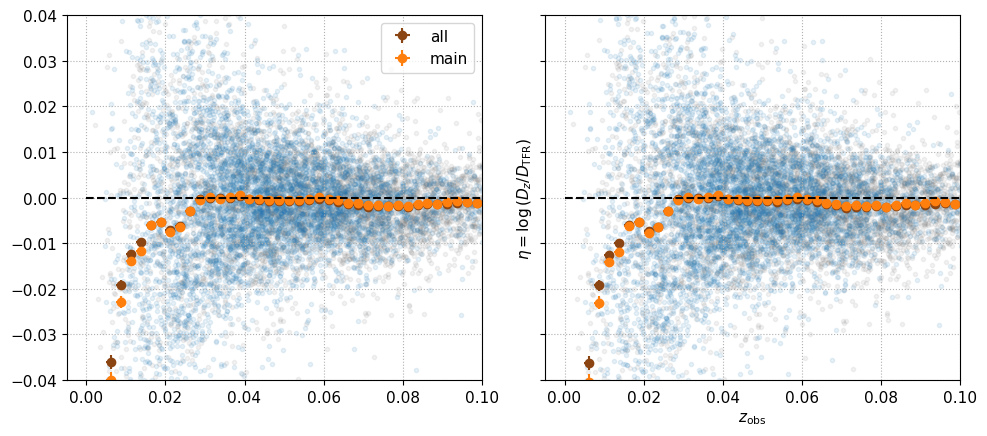

In [85]:
logdist_true = np.log10(cosmology.comoving_distance(mock['zobs'].to_numpy()).value/cosmology.comoving_distance(mock['zcos'].to_numpy()).value)

fig, axes = plt.subplots(1,2, figsize=(10,4.5), tight_layout=True, sharex=True, sharey=True)

ax = axes[0]
ax.scatter(mock['zobs'][~mock_main][::20], logdist_true[~mock_main][::20], 
           marker='.', 
           c='gray',
           alpha=0.1)
ax.scatter(mock['zobs'][mock_main][::20], logdist_true[mock_main][::20], 
           marker='.', alpha=0.1)

ax = axes[1]
ax.scatter(mock['zobs'][~mock_main][::20], eta_true[~mock_main][::20], 
           marker='.', 
           c='gray',
           alpha=0.1)
ax.scatter(mock['zobs'][mock_main][::20], eta_true[mock_main][::20], 
           marker='.', alpha=0.1)

zbins = np.arange(0, 0.1025, 0.0025)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

ax = axes[0]
_, eta_avg, eta_std = profile_histogram(mock['zobs'], logdist_true, zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='saddlebrown', label='all')
_, eta_avg, eta_std = profile_histogram(mock['zobs'][mock_main], logdist_true[mock_main], zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange', label='main')

ax.hlines(0, zbins[0], zbins[-1], colors='k', linestyles='dashed', zorder=10)
ax.grid(ls=':')

ax.legend()

ax = axes[1]
_, eta_avg, eta_std = profile_histogram(mock['zobs'], eta_true, zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='saddlebrown', label='all')
_, eta_avg, eta_std = profile_histogram(mock['zobs'][mock_main], eta_true[mock_main], zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange', label='main')

ax.hlines(0, zbins[0], zbins[-1], colors='k', linestyles='dashed', zorder=10)

ax.set(xlabel=r'$z_\mathrm{obs}$',
       xlim=(-0.005,0.1),
       # ylim=(-1,1),
       ylim=(-0.04, 0.04),
       ylabel=r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
ax.grid(ls=':');

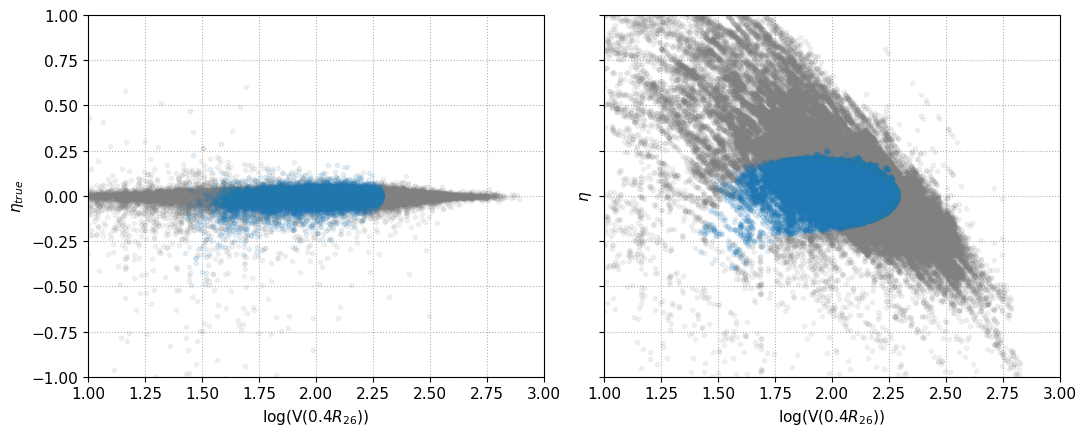

In [86]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5), tight_layout=True, sharex=True, sharey=True)

# Truth
ax = axes[0]
ax.plot(logvrot_mock[~mock_main], eta_true[~mock_main], '.', alpha=0.1, c='gray')
ax.plot(logvrot_mock[mock_main], eta_true[mock_main], '.', alpha=0.1)

ax.grid(ls=':')

ax.set(xlabel='log(V(0.4$R_{26}$))', 
       ylabel='$\eta_{true}$', 
       ylim=(-1, 1), 
       xlim=(1,3))


# Mock (generated)
ax = axes[1]
ax.plot(logvrot_mock[~mock_main], eta_mock[~mock_main], '.', alpha=0.1, c='gray')
ax.plot(logvrot_mock[mock_main], eta_mock[mock_main], '.', alpha=0.1)

ax.grid(ls=':')

ax.set(xlabel='log(V(0.4$R_{26}$))', 
       ylabel='$\eta$');

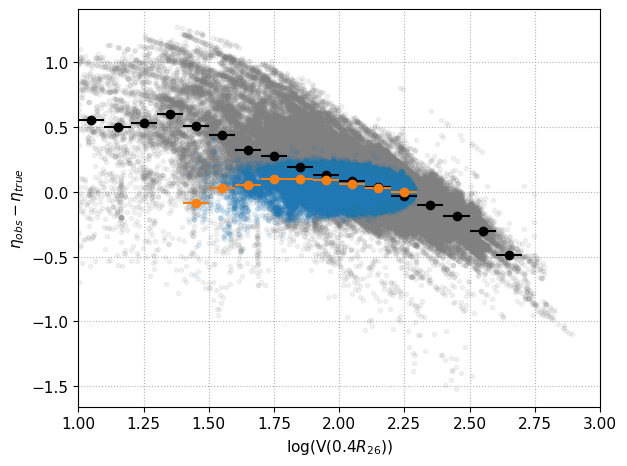

In [87]:
logv_bins = np.arange(1, 2.75, 0.1)
dv = 0.5*np.diff(logv_bins)
vc = 0.5*(logv_bins[1:] + logv_bins[:-1])

plt.figure(tight_layout=True)

plt.plot(logvrot_mock[~mock_main], 
         eta_mock[~mock_main] - eta_true[~mock_main], 
         '.', c='gray', alpha=0.1)

plt.plot(logvrot_mock[mock_main], 
         eta_mock[mock_main] - eta_true[mock_main], 
         '.', c='tab:blue', alpha=0.1)

_, dn_avg, dn_std = profile_histogram(logvrot_mock, eta_mock - eta_true, logv_bins, stat='median')
plt.errorbar(vc, dn_avg, xerr=dv, yerr=dn_std, fmt='o', color='black')

_, dn_avg, dn_std = profile_histogram(logvrot_mock[mock_main], 
                                      eta_mock[mock_main] - eta_true[mock_main], 
                                      logv_bins, 
                                      stat='median')
plt.errorbar(vc, dn_avg, xerr=dv, yerr=dn_std, fmt='o', color='tab:orange')

plt.grid(ls=':')

plt.xlim((1,3))

plt.xlabel('log(V(0.4$R_{26}$))')
plt.ylabel('$\eta_{obs} - \eta_{true}$');

### Correlation with magnitude

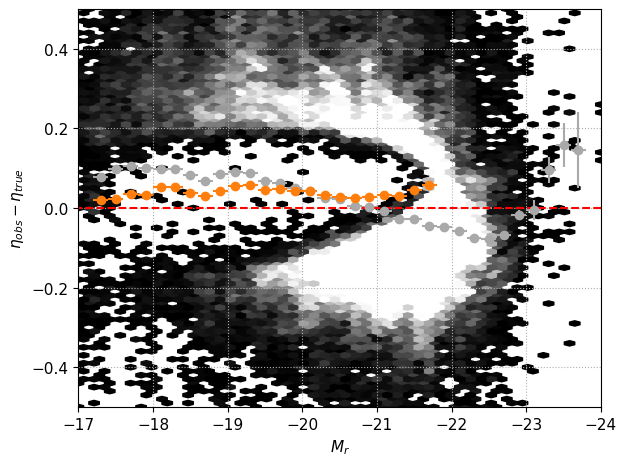

In [88]:
Mr_bins = np.arange(-24, -17, 0.2)
dMr = 0.5*np.diff(Mr_bins)
Mrc = 0.5*(Mr_bins[1:] + Mr_bins[:-1])

plt.figure(tight_layout=True)

plt.hexbin(mock['R_ABSMAG_SB26_MOCK'][~mock_main], 
           eta_mock[~mock_main] - eta_true[~mock_main], 
           cmap='Greys_r', 
           vmin=1, 
           vmax=50, 
           mincnt=1, 
           gridsize=(50, 50), 
           extent=(-24, -17, -0.5, 0.5))

# plt.hexbin(mock['R_ABSMAG_SB26_MOCK'][mock_main], 
#            eta_mock[mock_main] - eta_true[mock_main], 
#            cmap='viridis', 
#            vmin=1, 
#            vmax=400, 
#            mincnt=1, 
#            gridsize=(50, 50), 
#            extent=(-24, -17, -0.5, 0.5))

_, dn_avg, dn_std = profile_histogram(mock['R_ABSMAG_SB26_MOCK'], 
                                      eta_mock - eta_true, 
                                      Mr_bins, stat='median')
plt.errorbar(Mrc, dn_avg, xerr=dMr, yerr=dn_std, fmt='o', color='darkgrey')

_, dn_avg, dn_std = profile_histogram(mock['R_ABSMAG_SB26_MOCK'][mock_main], 
                                      eta_mock[mock_main] - eta_true[mock_main], 
                                      Mr_bins, 
                                      stat='median')
plt.errorbar(Mrc, dn_avg, xerr=dMr, yerr=dn_std, fmt='o', color='tab:orange')

plt.hlines(0, -24, -17, linestyles='dashed', colors='r')

plt.grid(ls=':')

plt.xlim((-17,-24))
plt.ylim(-0.5, 0.5)

plt.xlabel('$M_r$')
plt.ylabel('$\eta_{obs} - \eta_{true}$');

### Correlation with redshift

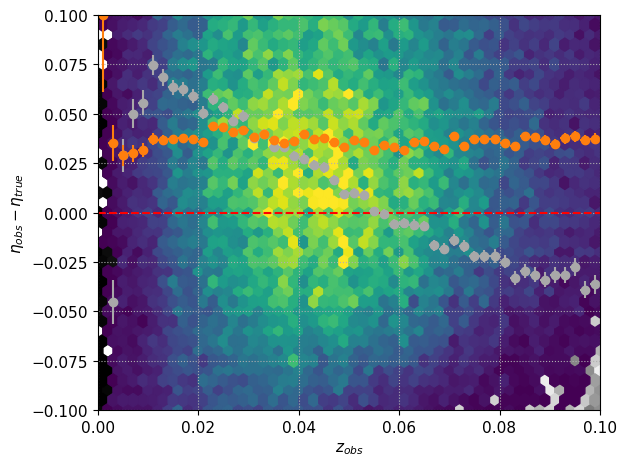

In [89]:
_zbins = np.arange(0, 0.2, 0.002)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])

plt.figure(tight_layout=True)

plt.hexbin(mock['zobs'][~mock_main], 
           eta_mock[~mock_main] - eta_true[~mock_main], 
           cmap='Greys_r', 
           vmin=1, 
           vmax=50, 
           mincnt=1, 
           gridsize=(50, 100), 
           extent=(0, 0.1, -0.5, 0.5))

plt.hexbin(mock['zobs'][mock_main], 
           eta_mock[mock_main] - eta_true[mock_main], 
           cmap='viridis', 
           vmin=1, 
           vmax=100, 
           mincnt=1, 
           gridsize=(50, 100), 
           extent=(0, 0.1, -0.5, 0.5))

_, dn_avg, dn_std = profile_histogram(mock['zobs'], 
                                      eta_mock - eta_true, 
                                      _zbins, stat='median')
plt.errorbar(zc, dn_avg, xerr=dz, yerr=dn_std, fmt='o', color='darkgrey')

_, dn_avg, dn_std = profile_histogram(mock['zobs'][mock_main], 
                                      eta_mock[mock_main] - eta_true[mock_main], 
                                      _zbins, 
                                      stat='median')
plt.errorbar(zc, dn_avg, xerr=dz, yerr=dn_std, fmt='o', color='tab:orange')

plt.hlines(0, 0, 0.1, linestyles='dashed', colors='r')

plt.grid(ls=':')

plt.xlim(0, 0.1)
plt.ylim(-0.1, 0.1)

plt.xlabel('$z_{obs}$')
plt.ylabel('$\eta_{obs} - \eta_{true}$');

In [90]:
# fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
# ax.hist((eta_mock - eta_true) / eta_err_mock, bins=np.arange(-10,10.2,0.2))
# ax.set(xlabel=r'$(\eta_\mathrm{mock} - \eta_\mathrm{true})/\sigma_\eta$',
#        yscale='log')

## Write Output to FITS

In [67]:
# # outfile = os.path.join('/global/cfs/cdirs/desi/science/td/pv/mocks/TF_mocks/fullmocks/v0.5.4',
# #                        os.path.basename(mockfile).replace('.dat.hdf5', '.fits').replace('BGS_PV', 'TF'))
# # outfile = os.path.join('/pscratch/sd/s/sgmoore1/TF/mocks/',
# #                        os.path.basename(mockfile).replace('.dat.hdf5', '.fits').replace('BGS_PV', 'TF'))
# outfile = f'/pscratch/sd/s/sgmoore1/TF/mocks/sys_tests/TF_Y1_mock_test_v10_{int(mock_num/60)}.fits'

# # hdr = fits.Header(dict(NTF=len(mock),
# #                        a=a_mcmc,
# #                        b=b_mcmc,
# #                        sigma=sigma_mcmc,
# #                        cov_aa=cov_mcmc[0][0],
# #                        cov_ab=cov_mcmc[0][1],
# #                        cov_as=cov_mcmc[0][2],
# #                        cov_bb=cov_mcmc[1][1],
# #                        cov_bs=cov_mcmc[1][2],
# #                        cov_ss=cov_mcmc[2][2]))

# hdr = fits.Header({ 'NTF' : len(mock) } | \
#                   {'mock': str(mockfile)} | \
#                   { 'a' : a} | \
#                   { 'b' : b} | \
#                   { 'sigma' : sigma_int} ) 

# col01 = fits.Column(name='RA',            format='D', array=mock['ra'].to_numpy())
# col02 = fits.Column(name='DEC',           format='D', array=mock['dec'].to_numpy())
# col03 = fits.Column(name='ZOBS',          format='D', array=mock['zobs'].to_numpy())
# col04 = fits.Column(name='ZCOS',          format='D', array=mock['zcos'].to_numpy())
# col05 = fits.Column(name='vx',            format='D', array=mock['vx'].to_numpy())
# col06 = fits.Column(name='vy',            format='D', array=mock['vy'].to_numpy())
# col07 = fits.Column(name='vz',            format='D', array=mock['vz'].to_numpy())
# col08 = fits.Column(name='DWARF',         format='L', array=mock['OUTLIER'].to_numpy())
# col09 = fits.Column(name='MAIN',          format='L', array=mock['MAIN'].to_numpy())
# col10 = fits.Column(name='LOGVROT',       format='D', array=mock['LOGVROT_MOCK'].to_numpy())
# col11 = fits.Column(name='R_ABSMAG_SB26', format='D', array=mock['R_ABSMAG_SB26_MOCK'].to_numpy())
# col12 = fits.Column(name='LOGDIST_TRUE',  format='D', array=eta_true)
# col13 = fits.Column(name='LOGDIST',       format='D', array=eta_mock)
# col14 = fits.Column(name='LOGDIST_ERR',   format='D', array=eta_err_mock)
# col15 = fits.Column(name='Y1_COMP',       format='D', array=mock['Y1_COMP'].to_numpy())
# col16 = fits.Column(name='Y3_COMP',       format='D', array=mock['Y3_COMP'].to_numpy())

# hdulist = fits.BinTableHDU.from_columns([col01, col02, col03, col04, col05,
#                                          col06, col07, col08, col09, col10,
#                                          col11, col12, col13, col14, col15,
#                                          col16],
#                                         header=hdr)
# hdulist.writeto(outfile, overwrite=True)

# # shutil.chown(outfile, group='desi')

In [40]:
mock_0 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_0_Snmin=0.fits')
mock_1 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_0_Snmin=0.001.fits')
mock_5 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_0_Snmin=0.005.fits')
mock_10 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_0_Snmin=0.01.fits')
mock_100 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_0_Snmin=0.1.fits')
mock_1000 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_0_Snmin=1.fits')

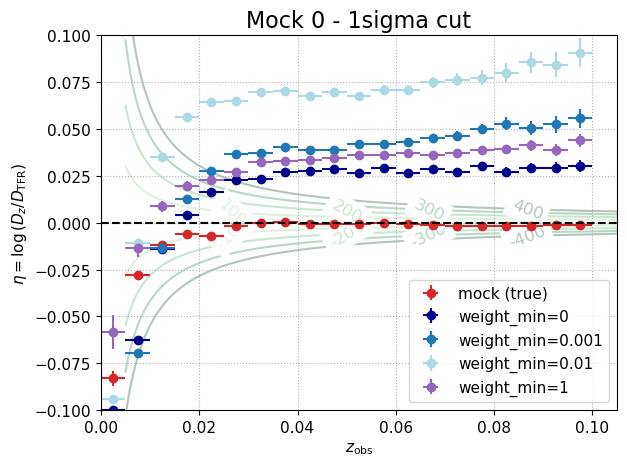

In [43]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST_TRUE'][mock_0['MAIN']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST'][mock_0['MAIN']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][mock_0['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][mock_1['MAIN']], 
                                        mock_1['LOGDIST'][mock_1['MAIN']], 
                                        _zbins, 
                                        weights=mock_1['LOGDIST_ERR'][mock_1['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][mock_10['MAIN']], 
                                        mock_10['LOGDIST'][mock_10['MAIN']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][mock_10['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

# _, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['MAIN']], 
#                                         mock_0['LOGDIST'][~mock_0['MAIN']], 
#                                         _zbins, 
#                                         weights=mock_0['LOGDIST_ERR'][~mock_0['MAIN']]**-2, 
#                                         weighted=True)
# plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][mock_1000['MAIN']], 
                                        mock_1000['LOGDIST'][mock_1000['MAIN']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][mock_1000['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 0 - 1sigma cut', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

/tmp/ipykernel_102343/1236354351.py:20: RuntimeWarning: divide by zero encountered in power
  weights=mock_0['LOGDIST_ERR'][~mock_0['OUTLIER_3SIG']]**-2,
/global/u1/s/sgmoore1/DESI_SGA/TF/help_functions.py:62: RuntimeWarning: invalid value encountered in true_divide
  h = H/W


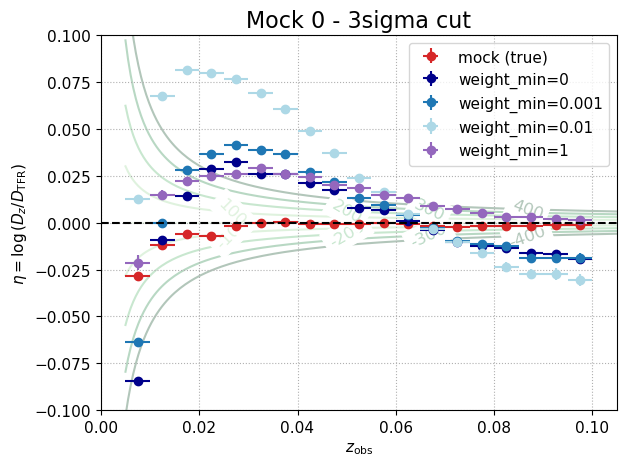

In [42]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['OUTLIER_3SIG']], 
                                        mock_0['LOGDIST_TRUE'][~mock_0['OUTLIER_3SIG']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['OUTLIER_3SIG']], 
                                        mock_0['LOGDIST'][~mock_0['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][~mock_0['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][~mock_1['OUTLIER_3SIG']], 
                                        mock_1['LOGDIST'][~mock_1['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_1['LOGDIST_ERR'][~mock_1['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][~mock_10['OUTLIER_3SIG']], 
                                        mock_10['LOGDIST'][~mock_10['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][~mock_10['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

# _, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['MAIN']], 
#                                         mock_0['LOGDIST'][~mock_0['MAIN']], 
#                                         _zbins, 
#                                         weights=mock_0['LOGDIST_ERR'][~mock_0['MAIN']]**-2, 
#                                         weighted=True)
# plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][~mock_1000['OUTLIER_3SIG']], 
                                        mock_1000['LOGDIST'][~mock_1000['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][~mock_1000['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 0 - 3sigma cut', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

In [69]:
mock_0 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_4_Snmin=0.fits')
mock_1 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_4_Snmin=0.001.fits')
mock_5 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_4_Snmin=0.005.fits')
mock_10 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_4_Snmin=0.01.fits')
mock_100 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_4_Snmin=0.1.fits')
mock_1000 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_4_Snmin=1.fits')

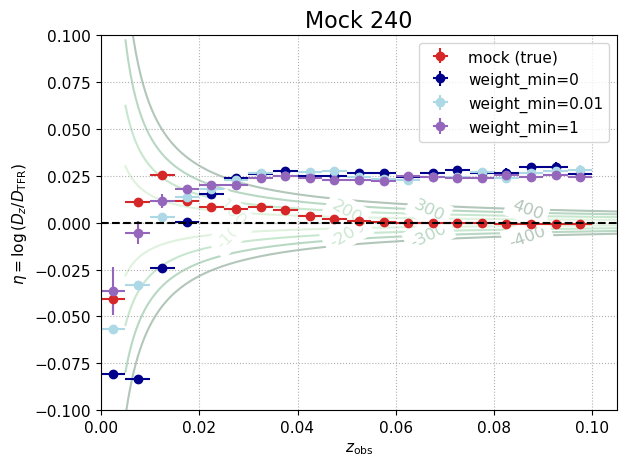

In [70]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST_TRUE'][mock_0['MAIN']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST'][mock_0['MAIN']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][mock_0['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

# _, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][mock_1['MAIN']], 
#                                         mock_1['LOGDIST'][mock_1['MAIN']], 
#                                         _zbins, 
#                                         weights=mock_1['LOGDIST_ERR'][mock_1['MAIN']]**-2, 
#                                         weighted=True)
# plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][mock_10['MAIN']], 
                                        mock_10['LOGDIST'][mock_10['MAIN']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][mock_10['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

# _, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['MAIN']], 
#                                         mock_0['LOGDIST'][~mock_0['MAIN']], 
#                                         _zbins, 
#                                         weights=mock_0['LOGDIST_ERR'][~mock_0['MAIN']]**-2, 
#                                         weighted=True)
# plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][mock_1000['MAIN']], 
                                        mock_1000['LOGDIST'][mock_1000['MAIN']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][mock_1000['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 240', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

In [44]:
mock_0 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_8_Snmin=0.fits')
mock_1 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_8_Snmin=0.001.fits')
mock_5 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_8_Snmin=0.005.fits')
mock_10 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_8_Snmin=0.01.fits')
mock_100 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_8_Snmin=0.1.fits')
mock_1000 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_8_Snmin=1.fits')

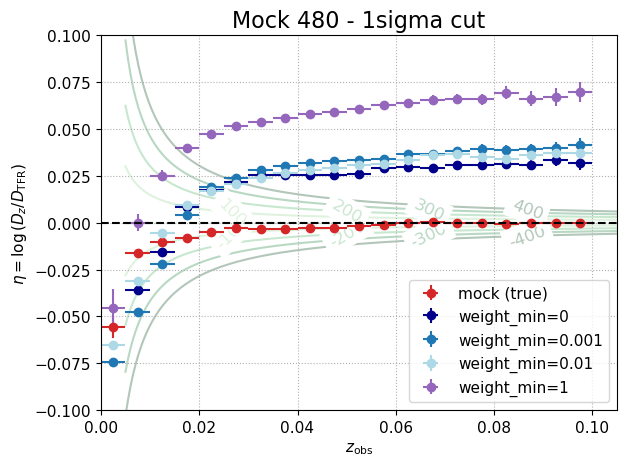

In [48]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST_TRUE'][mock_0['MAIN']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST'][mock_0['MAIN']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][mock_0['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][mock_1['MAIN']], 
                                        mock_1['LOGDIST'][mock_1['MAIN']], 
                                        _zbins, 
                                        weights=mock_1['LOGDIST_ERR'][mock_1['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][mock_10['MAIN']], 
                                        mock_10['LOGDIST'][mock_10['MAIN']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][mock_10['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][mock_1000['MAIN']], 
                                        mock_1000['LOGDIST'][mock_1000['MAIN']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][mock_1000['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 480 - 1sigma cut', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

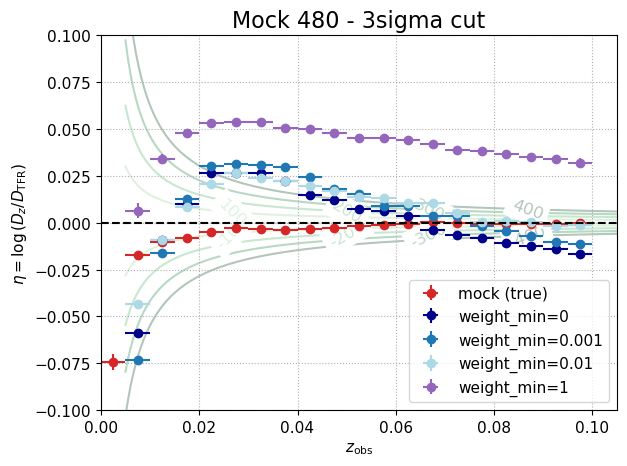

In [49]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['OUTLIER_3SIG']], 
                                        mock_0['LOGDIST_TRUE'][~mock_0['OUTLIER_3SIG']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['OUTLIER_3SIG']], 
                                        mock_0['LOGDIST'][~mock_0['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][~mock_0['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][~mock_1['OUTLIER_3SIG']], 
                                        mock_1['LOGDIST'][~mock_1['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_1['LOGDIST_ERR'][~mock_1['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][~mock_10['OUTLIER_3SIG']], 
                                        mock_10['LOGDIST'][~mock_10['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][~mock_10['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

# _, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][~mock_0['MAIN']], 
#                                         mock_0['LOGDIST'][~mock_0['MAIN']], 
#                                         _zbins, 
#                                         weights=mock_0['LOGDIST_ERR'][~mock_0['MAIN']]**-2, 
#                                         weighted=True)
# plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][~mock_1000['OUTLIER_3SIG']], 
                                        mock_1000['LOGDIST'][~mock_1000['OUTLIER_3SIG']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][~mock_1000['OUTLIER_3SIG']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 480 - 3sigma cut', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

In [73]:
mock_0 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_2_Snmin=0.fits')
mock_1 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_2_Snmin=0.001.fits')
mock_5 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_2_Snmin=0.005.fits')
mock_10 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_2_Snmin=0.01.fits')
mock_100 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_2_Snmin=0.1.fits')
mock_1000 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_2_Snmin=1.fits')

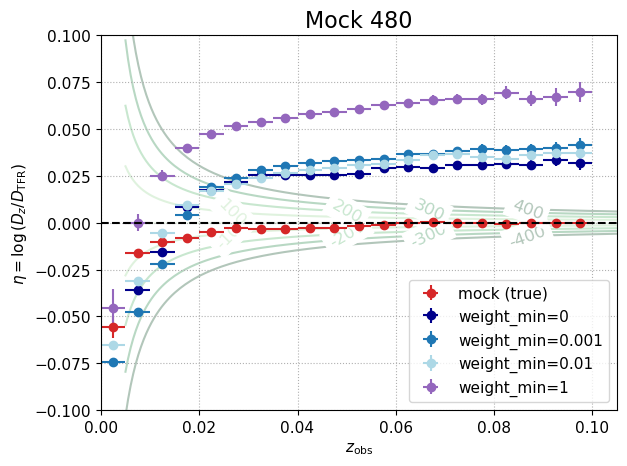

In [47]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST_TRUE'][mock_0['MAIN']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST'][mock_0['MAIN']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][mock_0['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][mock_1['MAIN']], 
                                        mock_1['LOGDIST'][mock_1['MAIN']], 
                                        _zbins, 
                                        weights=mock_1['LOGDIST_ERR'][mock_1['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][mock_10['MAIN']], 
                                        mock_10['LOGDIST'][mock_10['MAIN']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][mock_10['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][mock_1000['MAIN']], 
                                        mock_1000['LOGDIST'][mock_1000['MAIN']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][mock_1000['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend(loc='lower right')

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 480', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);

In [78]:
mock_0 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_6_Snmin=0.fits')
mock_1 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_6_Snmin=0.001.fits')
mock_5 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_6_Snmin=0.005.fits')
mock_10 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_6_Snmin=0.01.fits')
mock_100 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_6_Snmin=0.1.fits')
mock_1000 = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/TF_Y1_mock_test_v10_6_Snmin=1.fits')

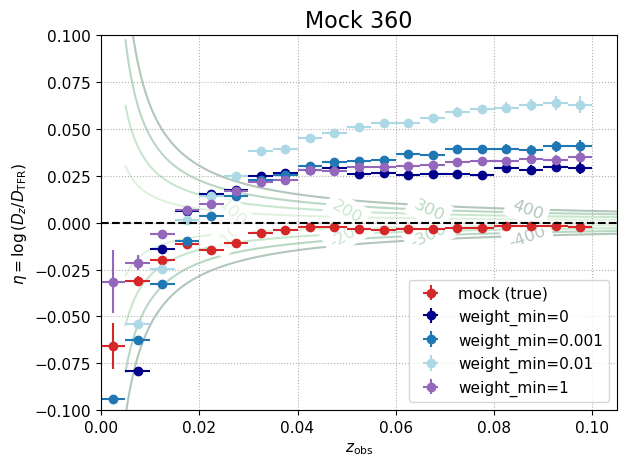

In [79]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST_TRUE'][mock_0['MAIN']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# # Mock
_, eta_avg, eta_std = profile_histogram(mock_0['ZOBS'][mock_0['MAIN']], 
                                        mock_0['LOGDIST'][mock_0['MAIN']], 
                                        _zbins, 
                                        weights=mock_0['LOGDIST_ERR'][mock_0['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='darkblue', label='weight_min=0')

_, eta_avg, eta_std = profile_histogram(mock_1['ZOBS'][mock_1['MAIN']], 
                                        mock_1['LOGDIST'][mock_1['MAIN']], 
                                        _zbins, 
                                        weights=mock_1['LOGDIST_ERR'][mock_1['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:blue', label='weight_min=0.001')

_, eta_avg, eta_std = profile_histogram(mock_10['ZOBS'][mock_10['MAIN']], 
                                        mock_10['LOGDIST'][mock_10['MAIN']], 
                                        _zbins, 
                                        weights=mock_10['LOGDIST_ERR'][mock_10['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='lightblue', label='weight_min=0.01')

_, eta_avg, eta_std = profile_histogram(mock_1000['ZOBS'][mock_1000['MAIN']], 
                                        mock_1000['LOGDIST'][mock_1000['MAIN']], 
                                        _zbins, 
                                        weights=mock_1000['LOGDIST_ERR'][mock_1000['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:purple', label='weight_min=1')



# Data
# _, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
#                                                   tfrcat['LOGDIST'][tfrcat['MAIN']], 
#                                                   _zbins, 
#                                                   weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
#                                                   weighted=True)
# plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend(loc='lower right')

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
plt.title('Mock 360', fontsize=16)
plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);
plt.ylim(-0.1, 0.1);

# fig.savefig('tfr_mock_eta.png', dpi=150);